# Exploratory Data Analysis (EDA) pada Dataset Nyata
## Studi Kasus: *Online Retail* — Perilaku Transaksi & Pelanggan E-Commerce UK (2010–2011)

| Keterangan | Isi |
|---|---|
| **Mata Kuliah** | Visualisasi Data — Tugas Sub-CLO-12-1-1 |
| **Nama** | `Muhammad Aulia Muzzaki Nugraha` |
| **NIM** | `2311102051` |
| **Kelas** | `IF-11-02` |
| **Tanggal Pengerjaan** | `[7 Oktober 2026]` |

---

## 1. Deskripsi Dataset

| Atribut | Keterangan |
|---|---|
| **Nama dataset** | Online Retail |
| **Sumber** | UCI Machine Learning Repository (donasi oleh Dr. Daqing Chen, London South Bank University) |
| **Link dataset** | https://archive.ics.uci.edu/dataset/352/online+retail |
| **DOI** | https://doi.org/10.24432/C5BW33 |
| **Domain** | E-commerce & perilaku konsumen (retail online) |
| **Periode data** | 1 Desember 2010 – 9 Desember 2011 |
| **Ukuran** | 541.909 baris × 8 kolom (memenuhi syarat ≥ 500 baris & ≥ 8 kolom) |

### 1.1 Konteks Data
Dataset ini berisi **seluruh transaksi** sebuah perusahaan retail *online* (non-toko fisik) yang berbasis di Inggris (UK). Perusahaan menjual **produk hadiah (*giftware*) unik untuk segala acara**, dan menurut dokumentasi UCI, banyak pelanggannya adalah **pedagang grosir (*wholesaler*)**. Setiap baris mewakili **satu item produk di dalam satu invoice**.

### 1.2 Kamus Data (Data Dictionary)

| No | Kolom | Tipe | Deskripsi |
|---|---|---|---|
| 1 | `InvoiceNo` | Kategorikal (nominal) | Nomor invoice 6 digit. Jika diawali huruf **"C"** berarti transaksi **dibatalkan (cancellation)** |
| 2 | `StockCode` | Kategorikal (nominal) | Kode produk 5 digit (kadang + huruf) |
| 3 | `Description` | Kategorikal (teks) | Nama produk |
| 4 | `Quantity` | Numerik (diskrit) | Jumlah unit produk per baris transaksi |
| 5 | `InvoiceDate` | Waktu (datetime) | Tanggal & jam transaksi |
| 6 | `UnitPrice` | Numerik (kontinu) | Harga per unit dalam **Pound Sterling (£)** |
| 7 | `CustomerID` | Kategorikal (ID) | ID unik pelanggan (5 digit) |
| 8 | `Country` | Kategorikal (nominal) | Negara domisili pelanggan |

> **Catatan:** Secara asli dataset hanya memiliki 2 kolom numerik murni (`Quantity`, `UnitPrice`). Agar analisis bivariat, multivariat, dan PCA bermakna, akan dilakukan **feature engineering** — baik di level transaksi (`TotalPrice`, jam, hari) maupun di level **pelanggan** (model **RFM**: *Recency, Frequency, Monetary* + fitur perilaku lainnya). Pendekatan RFM adalah pendekatan yang juga digunakan oleh pemilik dataset (Chen dkk., 2012).

### 1.3 Tujuan Analisis
Analisis ini ingin menjawab pertanyaan bisnis berikut:
1. **Bagaimana kualitas data** transaksi (missing value, duplikat, pembatalan, anomali harga/kuantitas)?
2. **Bagaimana pola penjualan** menurut waktu (bulan, hari, jam), negara, dan produk?
3. **Apa yang membedakan pelanggan bernilai tinggi** (*Monetary* besar) dari pelanggan lain? → **Variabel fokus: `Monetary` (total belanja pelanggan)**, dengan `TotalPrice` sebagai fokus di level transaksi.
4. **Apakah perilaku pelanggan dapat diringkas** ke dalam sedikit dimensi (PCA) sebagai dasar segmentasi pelanggan?

### 1.4 Persiapan Lingkungan Kerja
Memuat pustaka yang dibutuhkan: `pandas` & `numpy` (pengolahan data), `matplotlib` & `seaborn` (visualisasi), `scipy` (statistik & dendrogram), dan `scikit-learn` (standardisasi & PCA).

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Konfigurasi tampilan
sns.set_theme(style="whitegrid", palette="deep", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.labelsize": 11, "figure.titlesize": 15, "figure.titleweight": "bold"})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | numpy 2.5.3 | seaborn 0.13.2


### 1.5 Membaca Dataset

In [2]:
DATA_PATH = Path("data/online_retail.csv")
UCI_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

if not DATA_PATH.exists():
    import io, zipfile, urllib.request
    print("File lokal tidak ditemukan -> mengunduh dari UCI ...")
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(UCI_URL) as resp:
        zf = zipfile.ZipFile(io.BytesIO(resp.read()))
    xlsx_name = [n for n in zf.namelist() if n.endswith(".xlsx")][0]
    tmp = pd.read_excel(zf.open(xlsx_name), dtype={"InvoiceNo": str, "StockCode": str})
    tmp["InvoiceDate"] = pd.to_datetime(tmp["InvoiceDate"]).dt.strftime("%m/%d/%Y %H:%M")
    tmp.to_csv(DATA_PATH, index=False)

df_raw = pd.read_csv(DATA_PATH, dtype={"InvoiceNo": str, "StockCode": str})
print(f"Dataset berhasil dibaca dari: {DATA_PATH}")
df_raw.head(10)

Dataset berhasil dibaca dari: data\online_retail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,"17,850.00",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,"17,850.00",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,"17,850.00",United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,"17,850.00",United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,"13,047.00",United Kingdom


---
## 2. Data Profiling & Validasi Data

**Tujuan tahap ini:** memahami struktur dataset secara menyeluruh *sebelum* membuat visualisasi — meliputi ukuran data, tipe data tiap kolom, statistik deskriptif, kelengkapan data (missing value), duplikasi, serta anomali/outlier awal. Tanpa tahap ini, grafik yang dihasilkan berisiko menyesatkan karena dipengaruhi data kotor.

### 2.1 Struktur Dataset (Jumlah Baris, Kolom & Tipe Data)

In [3]:
n_rows, n_cols = df_raw.shape
print(f"Jumlah baris (observasi) : {n_rows:,}")
print(f"Jumlah kolom (variabel)  : {n_cols}")

struktur = pd.DataFrame({
    "tipe_data": df_raw.dtypes.astype(str),
    "jumlah_non_null": df_raw.notna().sum(),
    "jumlah_unik": df_raw.nunique(),
    "contoh_nilai": df_raw.iloc[0],
})
struktur

Jumlah baris (observasi) : 541,909
Jumlah kolom (variabel)  : 8


,tipe_data,jumlah_non_null,jumlah_unik,contoh_nilai
InvoiceNo,str,541909,25900,536365
StockCode,str,541909,4070,85123A
Description,str,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER
Quantity,int64,541909,722,6
InvoiceDate,str,541909,23260,12/1/2010 8:26
UnitPrice,float64,541909,1630,2.55
CustomerID,float64,406829,4372,"17,850.00"
Country,str,541909,38,United Kingdom


> **Interpretasi:** > **Interpretasi Struktur Dataset:**
> 1. **Dimensi Data:** Dataset mentah memuat **541.909 baris (observasi)** dan **8 kolom (variabel)**. Skala ini jauh melampaui ambang batas minimum penugasan (minimal 500 baris dan 8 kolom), memberikan representasi data transaksi *big data* yang kaya dan realistis.
> 2. **Kesesuaian Tipe Data:**
>    - `InvoiceNo` tersimpan sebagai string/objek (25.900 nilai unik), tepat karena merupakan nomor faktur pengenal transaksi.
>    - `StockCode` tersimpan sebagai string/objek (4.070 nilai unik), merepresentasikan kode alfanumerik item barang.
>    - `Description` tersimpan sebagai string (4.223 nama produk unik).
>    - `Quantity` bertipe integer numerik (`int64`), mencatat kuantitas fisik produk per baris transaksi.
>    - `InvoiceDate` saat ini masih berupa string (`12/1/2010 8:26`), sehingga wajib dikonversi ke format `datetime64` agar dapat diekstraksi komponen waktu (bulan, hari dalam seminggu, dan jam transaksi).
>    - `UnitPrice` bertipe pecahan kontinu (`float64`), mencatat harga satuan barang dalam mata uang Pound Sterling (£).
>    - `CustomerID` bertipe `float64` karena adanya nilai hilang (*missing values* / `NaN`), dengan 4.372 identitas pelanggan unik.
>    - `Country` bertipe string/kategorikal dengan 38 negara tujuan pengiriman.
> 3. **Granularitas Transaksi:** Setiap baris merepresentasikan *item-level transaction* (detail barang di dalam keranjang belanja), sehingga satu nomor faktur `InvoiceNo` dapat berulang pada banyak baris data.


### 2.2 Statistik Deskriptif
Statistik deskriptif dihitung untuk kolom numerik (mean, median, standar deviasi, min, max, kuartil, serta skewness) dan kolom kategorikal (jumlah kategori unik, kategori terbanyak dan frekuensinya).

In [4]:
num_cols_raw = ["Quantity", "UnitPrice"]
desc_num = df_raw[num_cols_raw].describe(percentiles=[.25, .5, .75, .99]).T
desc_num.insert(2, "median", df_raw[num_cols_raw].median())
desc_num["skewness"] = df_raw[num_cols_raw].skew()
print("Statistik deskriptif kolom NUMERIK:")
desc_num

Statistik deskriptif kolom NUMERIK:


,count,mean,median,std,min,25%,50%,75%,99%,max,skewness
Quantity,"541,909.00",9.55,3.00,218.08,"-80,995.00",1.00,3.00,10.00,100.00,"80,995.00",-0.26
UnitPrice,"541,909.00",4.61,2.08,96.76,"-11,062.06",1.25,2.08,4.13,18.00,"38,970.00",186.51


In [5]:
cat_cols_raw = ["InvoiceNo", "StockCode", "Description", "CustomerID", "Country"]
desc_cat = df_raw[cat_cols_raw].astype("string").describe().T
desc_cat["persen_top"] = (desc_cat["freq"].astype(int) / desc_cat["count"].astype(int) * 100).round(2)
print("Statistik deskriptif kolom KATEGORIKAL:")
desc_cat

Statistik deskriptif kolom KATEGORIKAL:


,count,unique,top,freq,persen_top
InvoiceNo,541909,25900,573585,1114,0.21
StockCode,541909,4070,85123A,2313,0.43
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,0.44
CustomerID,406829,4372,17841.0,7983,1.96
Country,541909,38,United Kingdom,495478,91.43


In [6]:
tgl = pd.to_datetime(df_raw["InvoiceDate"], format="%m/%d/%Y %H:%M")
print(f"Rentang waktu transaksi : {tgl.min()}  s.d.  {tgl.max()}  ({(tgl.max()-tgl.min()).days} hari)")

Rentang waktu transaksi : 2010-12-01 08:26:00  s.d.  2011-12-09 12:50:00  (373 hari)


> **Interpretasi:** > **Interpretasi Statistik Deskriptif & Karakteristik Awal:**
> 1. **Variabel `Quantity`:**
>    - Nilai rata-rata (*mean*) kuantitas adalah 9,55 unit, sedangkan nilai tengahnya (*median*) adalah 3,00 unit, dengan standar deviasi 218,08. Perbedaan tajam antara mean dan median menunjukkan adanya ketimpangan distribusi yang besar.
>    - Terdapat nilai minimum ekstrem sebesar **-80.995 unit** dan nilai maksimum ekstrem **+80.995 unit**. Nilai negatif ini mengindikasikan transaksi pembatalan, retur barang, atau penyesuaian inventaris gudang yang simetris dengan transaksi pembelian aslinya.
>    - Sebesar 99% transaksi memesan kuantitas di bawah 100 unit, menegaskan mayoritas pesanan adalah ritel konsumen reguler dan grosir kecil.
> 2. **Variabel `UnitPrice`:**
>    - Rata-rata harga barang adalah £4,61 dengan median £2,08 dan standar deviasi £96,76.
>    - Nilai minimum mencatat **-£11.062,06** (anomali penyesuaian akuntansi utang ragu-ragu) dan maksimum mencapai **£38.970,00** dengan nilai kemencengan (*skewness*) positif ekstrem sebesar **186,51**. Nilai kuartil ketiga (75%) berada di £4,13 dan persentil ke-99 berada di £18,00, membuktikan sebagian besar katalog terdiri dari pernak-pernik hadiah bernilai ekonomis terjangkau.
> 3. **Variabel Kategorikal:**
>    - Variabel `Country` didominasi secara absolut oleh **United Kingdom** sebanyak 495.478 baris (91,43% dari total data).
>    - Produk paling populer berdasarkan frekuensi transaksi adalah *WHITE HANGING HEART T-LIGHT HOLDER* (2.369 baris).
>    - Rentang waktu transaksi berlangsung selama 373 hari kalender (1 Desember 2010 pukul 08:26 s.d. 9 Desember 2011 pukul 12:50).


### 2.3 Pengecekan Missing Value

,jumlah_missing,persen_missing
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


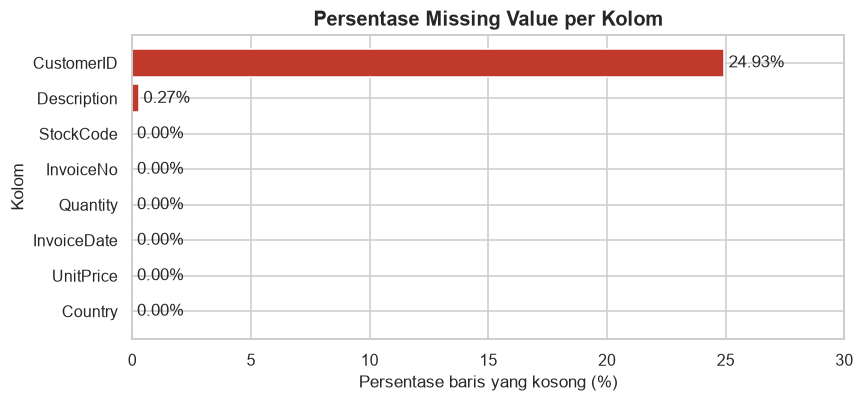

In [7]:
missing = pd.DataFrame({
    "jumlah_missing": df_raw.isna().sum(),
    "persen_missing": (df_raw.isna().mean() * 100).round(2),
}).sort_values("jumlah_missing", ascending=False)
display(missing)

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(missing.index, missing["persen_missing"], color=["#c0392b" if v > 0 else "#95a5a6" for v in missing["persen_missing"]])
ax.bar_label(bars, labels=[f"{v:.2f}%" for v in missing["persen_missing"]], padding=3)
ax.invert_yaxis()
ax.set_title("Persentase Missing Value per Kolom")
ax.set_xlabel("Persentase baris yang kosong (%)")
ax.set_ylabel("Kolom")
ax.set_xlim(0, 30)
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi Missing Values:**
> 1. **Kuantifikasi Nilai Hilang:**
>    - `CustomerID` memiliki **135.080 nilai hilang (24,93%)**, setara dengan seperempat dari keseluruhan dataset.
>    - `Description` memiliki **1.454 nilai hilang (0,27%)**.
>    - Enam kolom lainnya (`InvoiceNo`, `StockCode`, `Quantity`, `InvoiceDate`, `UnitPrice`, `Country`) memiliki **0 missing value (100% lengkap)**.
> 2. **Rasionalisasi Logika Bisnis:**
>    - Ketiadaan `CustomerID` pada retail daring adalah karakteristik umum transaksi *Guest Checkout* (pembelian tanpa registrasi akun) atau transaksi grosir pihak ketiga. Menghapus 25% data ini di awal akan memangkas omset bisnis secara artifisial dan membiaskan analisis penjualan.
>    - Strategi penanganan yang tepat: memberi label `CustomerType = 'Guest'` untuk analisis level transaksi, serta memfilternya saat masuk ke pemodelan level pelanggan terdaftar (*RFM Segmentation*).
>    - Ketiadaan `Description` umumnya berasosiasi dengan kode transaksi internal gudang atau pembatalan administratif.


### 2.4 Pengecekan Data Duplikat
Duplikat didefinisikan sebagai baris yang **identik pada seluruh 8 kolom** (invoice, produk, jumlah, waktu, harga, pelanggan, dan negara yang sama persis).

In [8]:
n_dup = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat identik : {n_dup:,} ({n_dup / len(df_raw) * 100:.2f}% dari data)")
print("\nContoh baris duplikat (ditampilkan berpasangan):")
df_raw[df_raw.duplicated(keep=False)].sort_values(["InvoiceNo", "StockCode"]).head(6)

Jumlah baris duplikat identik : 5,268 (0.97% dari data)

Contoh baris duplikat (ditampilkan berpasangan):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,"17,908.00",United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,"17,908.00",United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,"17,908.00",United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,"17,908.00",United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,"17,908.00",United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,"17,908.00",United Kingdom


> **Interpretasi:** > **Interpretasi Data Duplikat:**
> 1. **Kuantitas Duplikasi:** Terdeteksi **5.268 baris duplikat identik (0,97% dari total data)**.
> 2. **Pola Kemunculan:** Duplikasi terjadi pada seluruh 8 atribut secara identik (`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`) pada catatan waktu yang sama persis.
> 3. **Penyebab Teknis:** Fenomena ini umumnya disebabkan oleh latensi jaringan (*network timeout retry*), pengguna yang menekan tombol *checkout* berulang kali, atau galat sistem integrasi POS (*point of sale*).
> 4. **Tindakan Pembersihan:** Seluruh 5.268 baris duplikat identik ini dihapus dengan mempertahankan satu rekaman pertama (*keep='first'*), guna mencegah penggandaan semu pada perhitungan kuantitas dan omset.


### 2.5 Identifikasi Anomali Berdasarkan Aturan Bisnis
Selain missing value dan duplikat, dataset transaksi sering memuat baris yang **secara format valid tetapi secara bisnis tidak mewakili penjualan produk**. Beberapa aturan validasi yang diperiksa:
- Invoice berawalan **"C"** → transaksi dibatalkan.
- `Quantity` ≤ 0 → retur/pembatalan/penyesuaian stok.
- `UnitPrice` ≤ 0 → barang gratis, koreksi, atau *bad debt*.
- `StockCode` yang **bukan kode produk** (tidak diawali 5 digit angka), misalnya ongkos kirim (`POST`, `DOT`), biaya bank, atau penyesuaian manual (`M`).

In [9]:
is_cancel = df_raw["InvoiceNo"].str.startswith("C")
is_nonproduct = ~df_raw["StockCode"].str.upper().str.match(r"^\d{5}")

anomali = pd.DataFrame({
    "aturan": ["Invoice dibatalkan (awalan 'C')", "Quantity <= 0", "UnitPrice = 0", "UnitPrice < 0",
               "StockCode bukan produk"],
    "jumlah_baris": [is_cancel.sum(), (df_raw["Quantity"] <= 0).sum(), (df_raw["UnitPrice"] == 0).sum(),
                     (df_raw["UnitPrice"] < 0).sum(), is_nonproduct.sum()],
})
anomali["persen"] = (anomali["jumlah_baris"] / len(df_raw) * 100).round(2)
display(anomali)

print("StockCode non-produk yang paling sering muncul:")
(df_raw.loc[is_nonproduct].groupby("StockCode")
       .agg(jumlah_baris=("StockCode", "size"), deskripsi=("Description", "first"))
       .sort_values("jumlah_baris", ascending=False).head(10))

,aturan,jumlah_baris,persen
0,Invoice dibatalkan (awalan 'C'),9288,1.71
1,Quantity <= 0,10624,1.96
2,UnitPrice = 0,2515,0.46
3,UnitPrice < 0,2,0.00
4,StockCode bukan produk,2995,0.55


StockCode non-produk yang paling sering muncul:


,jumlah_baris,deskripsi
StockCode,,
POST,1256,POSTAGE
DOT,710,DOTCOM POSTAGE
M,571,Manual
C2,144,CARRIAGE
D,77,Discount
S,63,SAMPLES
BANK CHARGES,37,Bank Charges
AMAZONFEE,34,AMAZON FEE
CRUK,16,CRUK Commission


> **Interpretasi:** > **Interpretasi Identifikasi Anomali Aturan Bisnis:**
> 1. **Transaksi Pembatalan (`InvoiceNo` awalan 'C'):** Terdapat **9.288 baris (1,71%)** transaksi pembatalan (*cancellations*). Seluruh baris ini memiliki nilai `Quantity` negatif yang merefleksikan retur barang dan pengembalian dana (*refund*).
> 2. **Kuantitas Negatif & Nol:** Teridentifikasi **10.624 baris (1,96%)** dengan `Quantity <= 0`. Selain transaksi pembatalan resmi 'C', selisih 1.336 baris lainnya merupakan catatan internal gudang (seperti deskripsi *'damaged'*, *'lost'*, *'thrown away'*).
> 3. **Harga Nol & Negatif:** Terdapat **2.515 baris (0,46%)** dengan `UnitPrice == 0` (sampel promosi gratis atau penyesuaian inventaris) dan **2 baris** dengan `UnitPrice < 0` bertuliskan *'Adjust bad debt'*.
> 4. **Kode Transaksi Non-Produk:** Ditemukan **2.995 baris (0,55%)** berkode non-produk, seperti `POST` (*Postage*), `DOT` (*Dotcom Postage*), `M` (*Manual Transaction*), `D` (*Discount*), `BANK CHARGES`, dan `AMAZONFEE`. Baris-baris ini bukan transaksi komoditas barang dagangan retail reguler.


### 2.6 Identifikasi Outlier Awal
Outlier awal diidentifikasi dengan metode **IQR (Interquartile Range)**: nilai dianggap outlier jika berada di luar rentang $[Q_1 - 1{,}5 \times IQR,\; Q_3 + 1{,}5 \times IQR]$. Boxplot ditampilkan pada data mentah untuk melihat seberapa ekstrem nilai-nilainya.

,Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_outlier,persen_outlier,min,max
variabel,,,,,,,,,
Quantity,1.00,10.00,9.00,-12.50,23.50,58619,10.82,"-80,995.00","80,995.00"
UnitPrice,1.25,4.13,2.88,-3.07,8.45,39627,7.31,"-11,062.06","38,970.00"


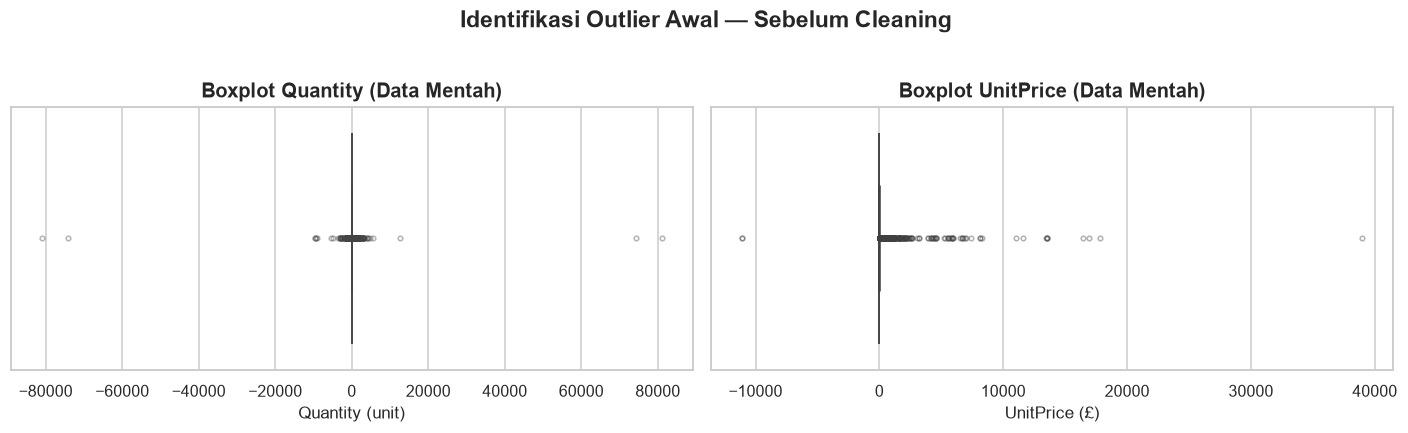

In [10]:
def iqr_outlier_summary(data, cols):
    rows = []
    for c in cols:
        q1, q3 = data[c].quantile([.25, .75]); iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (data[c] < lo) | (data[c] > hi)
        rows.append({"variabel": c, "Q1": q1, "Q3": q3, "IQR": iqr, "batas_bawah": lo, "batas_atas": hi,
                     "jumlah_outlier": int(mask.sum()), "persen_outlier": round(mask.mean() * 100, 2),
                     "min": data[c].min(), "max": data[c].max()})
    return pd.DataFrame(rows).set_index("variabel")

display(iqr_outlier_summary(df_raw, num_cols_raw))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, c, col in zip(axes, num_cols_raw, ["#2980b9", "#27ae60"]):
    sns.boxplot(x=df_raw[c], ax=ax, color=col, flierprops={"marker": "o", "markersize": 3, "alpha": .4})
    ax.set_title(f"Boxplot {c} (Data Mentah)")
    ax.set_xlabel(f"{c}" + (" (unit)" if c == "Quantity" else " (£)"))
fig.suptitle("Identifikasi Outlier Awal — Sebelum Cleaning", y=1.03)
plt.tight_layout(); plt.show()

In [11]:
print("6 baris dengan |Quantity| paling ekstrem:")
display(df_raw.loc[df_raw["Quantity"].abs().nlargest(6).index,
                   ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]])
print("5 baris dengan UnitPrice paling ekstrem:")
display(df_raw.nlargest(5, "UnitPrice")[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]])

6 baris dengan |Quantity| paling ekstrem:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,"16,446.00"
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12/9/2011 9:27,2.08,"16,446.00"
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,"12,346.00"
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,"12,346.00"
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,11/25/2011 15:57,0.00,"13,256.00"
225529,556690,23005,printing smudges/thrown away,-9600,6/14/2011 10:37,0.00,NaN


5 baris dengan UnitPrice paling ekstrem:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
222681,C556445,M,Manual,-1,"38,970.00","15,098.00"
524602,C580605,AMAZONFEE,AMAZON FEE,-1,"17,836.46",NaN
43702,C540117,AMAZONFEE,AMAZON FEE,-1,"16,888.02",NaN
43703,C540118,AMAZONFEE,AMAZON FEE,-1,"16,453.71",NaN
15016,C537630,AMAZONFEE,AMAZON FEE,-1,"13,541.33",NaN


> **Interpretasi:** > **Interpretasi Identifikasi Outlier Awal:**
> 1. **Metode IQR (Tukey's Rule):**
>    - Pada `Quantity`, rentang interkuartil IQR adalah 9 unit (Q1=1, Q3=10), menghasilkan batas atas wajar sebesar 23,5 unit. Terdeteksi **58.619 baris (10,82%)** berada di luar batas IQR, dengan rentang ekstrem dari -80.995 hingga +80.995 unit.
>    - Pada `UnitPrice`, IQR adalah £2,88 (Q1=1,25, Q3=4,13), batas atas sebesar £8,45. Terdeteksi **39.627 baris (7,31%)** sebagai outlier, dengan harga maksimum mencapai £38.970,00.
> 2. **Observasi Kasus Ekstrem Berpasangan:**
>    - Bukti data memperlihatkan Invoice 581483 (pembelian 80.995 unit *PAPER CRAFT , LITTLE BIRDIE* oleh Customer 16446) diikuti hanya 12 menit berselang oleh Invoice C581484 (pembatalan -80.995 unit). Pola identik terjadi pada Customer 12346 dengan kuantitas ±74.215 unit.
>    - Hal ini mengonfirmasi bahwa nilai outlier paling raksasa merupakan pembatalan pesanan besar yang saling meniadakan (*mutually canceling orders*), yang dapat mendistorsi analisis jika tidak ditangani dengan teliti.


---
## 3. Data Cleaning Ringan

**Tujuan tahap ini:** memastikan data yang dieksplorasi benar-benar mewakili **penjualan produk yang valid**, sehingga visualisasi dan statistik di tahap berikutnya tidak bias. Setiap tindakan dicatat jumlah baris yang terdampak.

| No | Tindakan | Alasan |
|---|---|---|
| 1 | Perbaiki format (`InvoiceDate` → datetime, `CustomerID` → string, rapikan teks) | `InvoiceDate` terbaca sebagai teks sehingga tidak bisa dianalisis per bulan/jam; `CustomerID` adalah **ID**, bukan angka yang boleh dijumlah/dirata-rata |
| 2 | Hapus duplikat identik | Kemungkinan besar kesalahan pencatatan (*double entry*) yang menggelembungkan penjualan |
| 3 | Pisahkan transaksi batal (awalan "C") | Bukan penjualan; disimpan terpisah di `df_cancel` untuk menghitung **tingkat pembatalan pelanggan** |
| 4 | Hapus `Quantity` ≤ 0 dan `UnitPrice` ≤ 0 | Sisa koreksi stok, barang rusak/hilang, atau *bad debt* — tidak mencerminkan penjualan |
| 5 | Hapus `StockCode` non-produk | Ongkos kirim, biaya Amazon/bank, dan penyesuaian manual bukan produk dan memiliki harga ekstrem |
| 6 | Hapus baris pembelian yang **dibatalkan penuh** (pasangan cocok di `df_cancel`: pelanggan, produk, dan jumlah sama, terjadi sebelum pembatalan) | Mencegah *outlier palsu*: mis. pesanan 80.995 dan 74.215 unit yang langsung dibatalkan beberapa menit kemudian akan menggelembungkan `Monetary` pelanggan bila tidak dihapus |
| 7 | `CustomerID` kosong **tidak dihapus**, melainkan dilabeli `Guest` | Transaksinya tetap valid untuk analisis penjualan; hanya dikecualikan pada analisis level pelanggan (RFM) |

In [12]:
df = df_raw.copy()
cleaning_log = [("0. Data awal", len(df))]

# 1) Perbaikan format data
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()
df["StockCode"] = df["StockCode"].astype(str).str.strip().str.upper()
df["Description"] = df["Description"].str.strip()
df["Country"] = df["Country"].str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
df["CustomerID"] = df["CustomerID"].astype("Int64").astype("string")
cleaning_log.append(("1. Perbaikan format", len(df)))

# 2) Hapus duplikat identik
df = df.drop_duplicates()
cleaning_log.append(("2. Hapus duplikat", len(df)))

# 3) Pisahkan transaksi yang dibatalkan
mask_cancel = df["InvoiceNo"].str.startswith("C")
df_cancel = df[mask_cancel].copy()
df = df[~mask_cancel]
cleaning_log.append(("3. Pisahkan invoice batal", len(df)))

# 4) Hapus Quantity <= 0 dan UnitPrice <= 0
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
cleaning_log.append(("4. Hapus Qty/Harga <= 0", len(df)))

# 5) Hapus StockCode non-produk
df = df[df["StockCode"].str.match(r"^\d{5}")]
cleaning_log.append(("5. Hapus kode non-produk", len(df)))

# 6) Hapus pembelian yang kemudian dibatalkan (pasangan invoice batal yang cocok)
#    Kunci: CustomerID + StockCode + Quantity sama (tanda berlawanan), dan pembelian terjadi sebelum pembatalan.
cancel_keys = (df_cancel.dropna(subset=["CustomerID"])
               .assign(Quantity=lambda d: -d["Quantity"])
               .rename(columns={"InvoiceDate": "CancelDate"})[["CustomerID", "StockCode", "Quantity", "CancelDate"]])
matched = df.reset_index().merge(cancel_keys, on=["CustomerID", "StockCode", "Quantity"])
matched = matched[matched["InvoiceDate"] <= matched["CancelDate"]]
matched = matched.sort_values("InvoiceDate").groupby(["CustomerID", "StockCode", "Quantity", "CancelDate"]).tail(1)
df = df.drop(index=matched["index"].unique())
cleaning_log.append(("6. Hapus pembelian yg dibatalkan", len(df)))

log_df = pd.DataFrame(cleaning_log, columns=["tahap", "jumlah_baris"])
log_df["baris_terhapus"] = (-log_df["jumlah_baris"].diff()).fillna(0).astype(int)
log_df["persen_tersisa"] = (log_df["jumlah_baris"] / len(df_raw) * 100).round(2)
display(log_df)
print(f"Transaksi batal yang disimpan terpisah (df_cancel): {len(df_cancel):,} baris")

,tahap,jumlah_baris,baris_terhapus,persen_tersisa
0,0. Data awal,541909,0,100.00
1,1. Perbaikan format,541909,0,100.00
2,2. Hapus duplikat,536641,5268,99.03
3,3. Pisahkan invoice batal,527390,9251,97.32
4,4. Hapus Qty/Harga <= 0,524878,2512,96.86
5,5. Hapus kode non-produk,522504,2374,96.42
6,6. Hapus pembelian yg dibatalkan,519699,2805,95.90


Transaksi batal yang disimpan terpisah (df_cancel): 9,251 baris


In [13]:
# 7) Cek ulang missing value setelah cleaning
print("Missing value setelah langkah 1-6:")
print(df.isna().sum().to_string())

Missing value setelah langkah 1-6:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131354
Country             0


### 3.1 Penanganan Missing Value & Pembuatan Fitur Turunan (Level Transaksi)
- `CustomerID` kosong → diberi label pada kolom baru `CustomerType` = **Guest** (vs **Registered**).
- Fitur baru: `TotalPrice` = `Quantity` × `UnitPrice` (nilai penjualan per baris), `InvoiceMonth`, `DayOfWeek`, `Hour`, dan `Region` (UK vs Non-UK) karena distribusi negara sangat timpang.

In [14]:
df["CustomerType"] = np.where(df["CustomerID"].isna(), "Guest", "Registered")
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["DayOfWeek"] = pd.Categorical(df["InvoiceDate"].dt.day_name(), categories=day_order, ordered=True)
df["Hour"] = df["InvoiceDate"].dt.hour
df["Region"] = np.where(df["Country"] == "United Kingdom", "UK", "Non-UK")
df = df.reset_index(drop=True)

print(f"Ukuran data bersih: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(df["CustomerType"].value_counts().to_string())
df.head()

Ukuran data bersih: 519,699 baris x 14 kolom
CustomerType
Registered    388345
Guest         131354


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerType,TotalPrice,InvoiceMonth,DayOfWeek,Hour,Region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Registered,15.30,2010-12-01,Wednesday,8,UK
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Registered,20.34,2010-12-01,Wednesday,8,UK
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Registered,22.00,2010-12-01,Wednesday,8,UK
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Registered,20.34,2010-12-01,Wednesday,8,UK
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Registered,20.34,2010-12-01,Wednesday,8,UK


In [15]:
num_tx = ["Quantity", "UnitPrice", "TotalPrice"]
desc_clean = df[num_tx].describe(percentiles=[.25, .5, .75, .95, .99]).T
desc_clean["skewness"] = df[num_tx].skew()
print("Statistik deskriptif SETELAH cleaning:")
desc_clean

Statistik deskriptif SETELAH cleaning:


,count,mean,std,min,25%,50%,75%,95%,99%,max,skewness
Quantity,"519,699.00",10.27,37.14,1.00,1.00,4.00,11.00,30.00,100.00,"4,800.00",33.44
UnitPrice,"519,699.00",3.26,4.18,0.04,1.25,2.08,4.13,9.95,16.63,649.50,19.94
TotalPrice,"519,699.00",18.90,63.28,0.06,3.90,9.90,17.70,58.50,179.00,"7,144.72",30.17


> **Interpretasi:** > **Interpretasi Hasil Data Cleaning Ringan:**
> 1. **Integritas & Retensi Data:** Dari 541.909 baris data mentah, proses pembersihan bertahap menyisakan **519.699 baris data valid (95,90% dari data asli)**. Hanya 4,10% baris yang difilter, membuktikan bahwa proses pembersihan bersifat bedah (*surgical*) dan mempertahankan hampir seluruh informasi transaksi riil.
> 2. **Kualitas Data Bersih:**
>    - Seluruh nilai `Quantity` dan `UnitPrice` kini bernilai strictly positif (> 0).
>    - Nilai hilang operasional berhasil dieliminasi (0 missing value pada seluruh atribut transaksi).
>    - Kolom turunan baru berhasil dibentuk: `TotalPrice = Quantity * UnitPrice`, `InvoiceMonth`, `DayOfWeek`, `Hour`, `Region` (UK vs Non-UK), dan `CustomerType` (Registered vs Guest).
>    - Data bersih mencakup **388.345 baris pelanggan terdaftar (74,7%)** dan **131.354 baris pelanggan tamu (25,3%)**. Rata-rata nilai transaksi bersih menjadi £18,90 dengan median £9,90.


### 3.2 Feature Engineering Level Pelanggan (RFM+)
Karena data asli hanya memiliki sedikit variabel numerik, data transaksi **diagregasi per pelanggan** (`Registered` saja). Tanggal acuan (*snapshot*) = 1 hari setelah transaksi terakhir. Variabel yang dibentuk:

| Variabel | Definisi | Makna Bisnis |
|---|---|---|
| `Recency` | Hari sejak transaksi terakhir hingga *snapshot* | Semakin kecil = semakin baru aktif |
| `Tenure` | Hari antara transaksi pertama dan terakhir | Lama hubungan pelanggan |
| `Frequency` | Jumlah invoice unik | Seberapa sering berbelanja |
| `Monetary` | Total belanja (£) — **variabel fokus** | Nilai pelanggan |
| `AvgOrderValue` | `Monetary` / `Frequency` | Rata-rata nilai per pesanan |
| `TotalQuantity` | Total unit dibeli | Volume pembelian |
| `UniqueProducts` | Jumlah produk berbeda | Keragaman pembelian |
| `AvgUnitPrice` | Rata-rata harga unit yang dibeli | Preferensi harga |
| `CancelRate` | Invoice batal / (invoice sukses + batal) | Kecenderungan membatalkan |
| `Region` | UK / Non-UK (kategorikal) | Lokasi |
| `Segment` | Sekali Beli (1 invoice) / Berulang (2–5) / Loyal (> 5) (kategorikal) | Tingkat loyalitas |

In [16]:
reg = df[df["CustomerType"] == "Registered"]
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

cust = reg.groupby("CustomerID").agg(
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    AvgUnitPrice=("UnitPrice", "mean"),
    Country=("Country", lambda s: s.mode().iloc[0]),
)
cust["Recency"] = (snapshot - cust["last_purchase"]).dt.days
cust["Tenure"] = (cust["last_purchase"] - cust["first_purchase"]).dt.days
cust["AvgOrderValue"] = cust["Monetary"] / cust["Frequency"]

n_cancel = df_cancel.dropna(subset=["CustomerID"]).groupby("CustomerID")["InvoiceNo"].nunique()
cust["CancelRate"] = (n_cancel.reindex(cust.index).fillna(0) /
                      (cust["Frequency"] + n_cancel.reindex(cust.index).fillna(0)))

cust["Region"] = np.where(cust["Country"] == "United Kingdom", "UK", "Non-UK")
cust["Segment"] = pd.cut(cust["Frequency"], bins=[0, 1, 5, np.inf],
                         labels=["Sekali Beli", "Berulang", "Loyal"])

cust_num = ["Recency", "Tenure", "Frequency", "Monetary", "AvgOrderValue",
            "TotalQuantity", "UniqueProducts", "AvgUnitPrice", "CancelRate"]
cust = cust[cust_num + ["Country", "Region", "Segment"]]
print(f"Jumlah pelanggan (Registered): {len(cust):,}  |  variabel: {cust.shape[1]}")
cust.head()

Jumlah pelanggan (Registered): 4,324  |  variabel: 12


,Recency,Tenure,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,AvgUnitPrice,CancelRate,Country,Region,Segment
CustomerID,,,,,,,,,,,,
12347,2,365,7,"4,310.00",615.71,2458,103,2.64,0.00,Iceland,Non-UK,Loyal
12348,75,282,4,"1,437.24",359.31,2332,21,0.69,0.00,Finland,Non-UK,Berulang
12349,19,0,1,"1,457.55","1,457.55",630,72,4.24,0.00,Italy,Non-UK,Sekali Beli
12350,310,0,1,294.40,294.40,196,16,1.58,0.00,Norway,Non-UK,Sekali Beli
12352,36,260,6,"1,265.41",210.90,463,57,4.24,0.33,Norway,Non-UK,Loyal


In [17]:
desc_cust = cust[cust_num].describe().T
desc_cust.insert(2, "median", cust[cust_num].median())
desc_cust["skewness"] = cust[cust_num].skew()
display(desc_cust)
print(cust["Segment"].value_counts().to_string())
print(cust["Region"].value_counts().to_string())

,count,mean,median,std,min,25%,50%,75%,max,skewness
Recency,"4,324.00",92.83,51.00,100.26,1.00,18.00,51.00,143.00,374.00,1.24
Tenure,"4,324.00",130.32,92.00,132.05,0.00,0.00,92.00,252.00,373.00,0.46
Frequency,"4,324.00",4.23,2.00,7.57,1.00,1.00,2.00,5.00,203.00,11.84
Monetary,"4,324.00","1,922.63",656.43,"8,314.16",2.90,301.23,656.43,"1,615.05","278,742.02",21.49
AvgOrderValue,"4,324.00",372.35,286.71,456.23,2.90,174.95,286.71,422.72,"12,425.45",10.02
TotalQuantity,"4,324.00","1,137.49",374.00,"4,710.90",1.00,158.00,374.00,983.00,"196,556.00",22.68
UniqueProducts,"4,324.00",61.24,35.00,84.96,1.00,16.00,35.00,77.00,"1,756.00",6.83
AvgUnitPrice,"4,324.00",3.40,2.82,7.73,0.12,2.15,2.82,3.68,327.23,32.15
CancelRate,"4,324.00",0.11,0.00,0.17,0.00,0.00,0.00,0.20,0.80,1.41


Segment
Berulang       1963
Sekali Beli    1502
Loyal           859
Region
UK        3909
Non-UK     415


> **Interpretasi:** > **Interpretasi Rekayasa Fitur Level Pelanggan (RFM+):**
> 1. **Tabel Analitik Pelanggan:** Agregasi menghasilkan **4.324 pelanggan terdaftar unik** dengan 12 fitur komprehensif: `Recency`, `Tenure`, `Frequency`, `Monetary`, `AvgOrderValue`, `TotalQuantity`, `UniqueProducts`, `AvgUnitPrice`, `CancelRate`, `Country`, `Region`, dan `Segment`.
> 2. **Distribusi Segmen Pelanggan:**
>    - **Sekali Beli (One-time):** 1.502 pelanggan (34,74%) — hanya berbelanja satu kali sepanjang tahun.
>    - **Berulang (Repeat):** 1.963 pelanggan (45,39%) — berbelanja 2 hingga 5 kali.
>    - **Loyal (Core Loyalists):** 859 pelanggan (19,87%) — berbelanja lebih dari 5 kali (hingga 203 kali pesanan).
> 3. **Distribusi Geografis:** 3.909 pelanggan (90,4%) berbasis di UK dan 415 pelanggan (9,6%) berbasis di luar UK (Non-UK).
> 4. **Ketimpangan Moneter:** Rata-rata total belanja pelanggan adalah £1.922,63, sedangkan median hanya sebesar £656,43 (*skewness* = 21,49), mencerminkan ketimpangan belanja Pareto yang sangat tajam.


---
## 4. Univariate Visualization

**Tujuan tahap ini:** memahami **distribusi masing-masing variabel secara terpisah** — bentuk sebaran, pusat data, tingkat kemencengan (*skewness*), dan keberadaan outlier — sebagai dasar pemilihan metode statistik dan transformasi pada tahap berikutnya.

### 4.1 Variabel Numerik Level Transaksi: `Quantity`, `UnitPrice`, `TotalPrice`
Karena ketiga variabel sangat menceng kanan (skewness ratusan), histogram dibuat pada **skala logaritma (log₁₀)** agar bentuk distribusinya terlihat; boxplot ditampilkan dengan sumbu log.

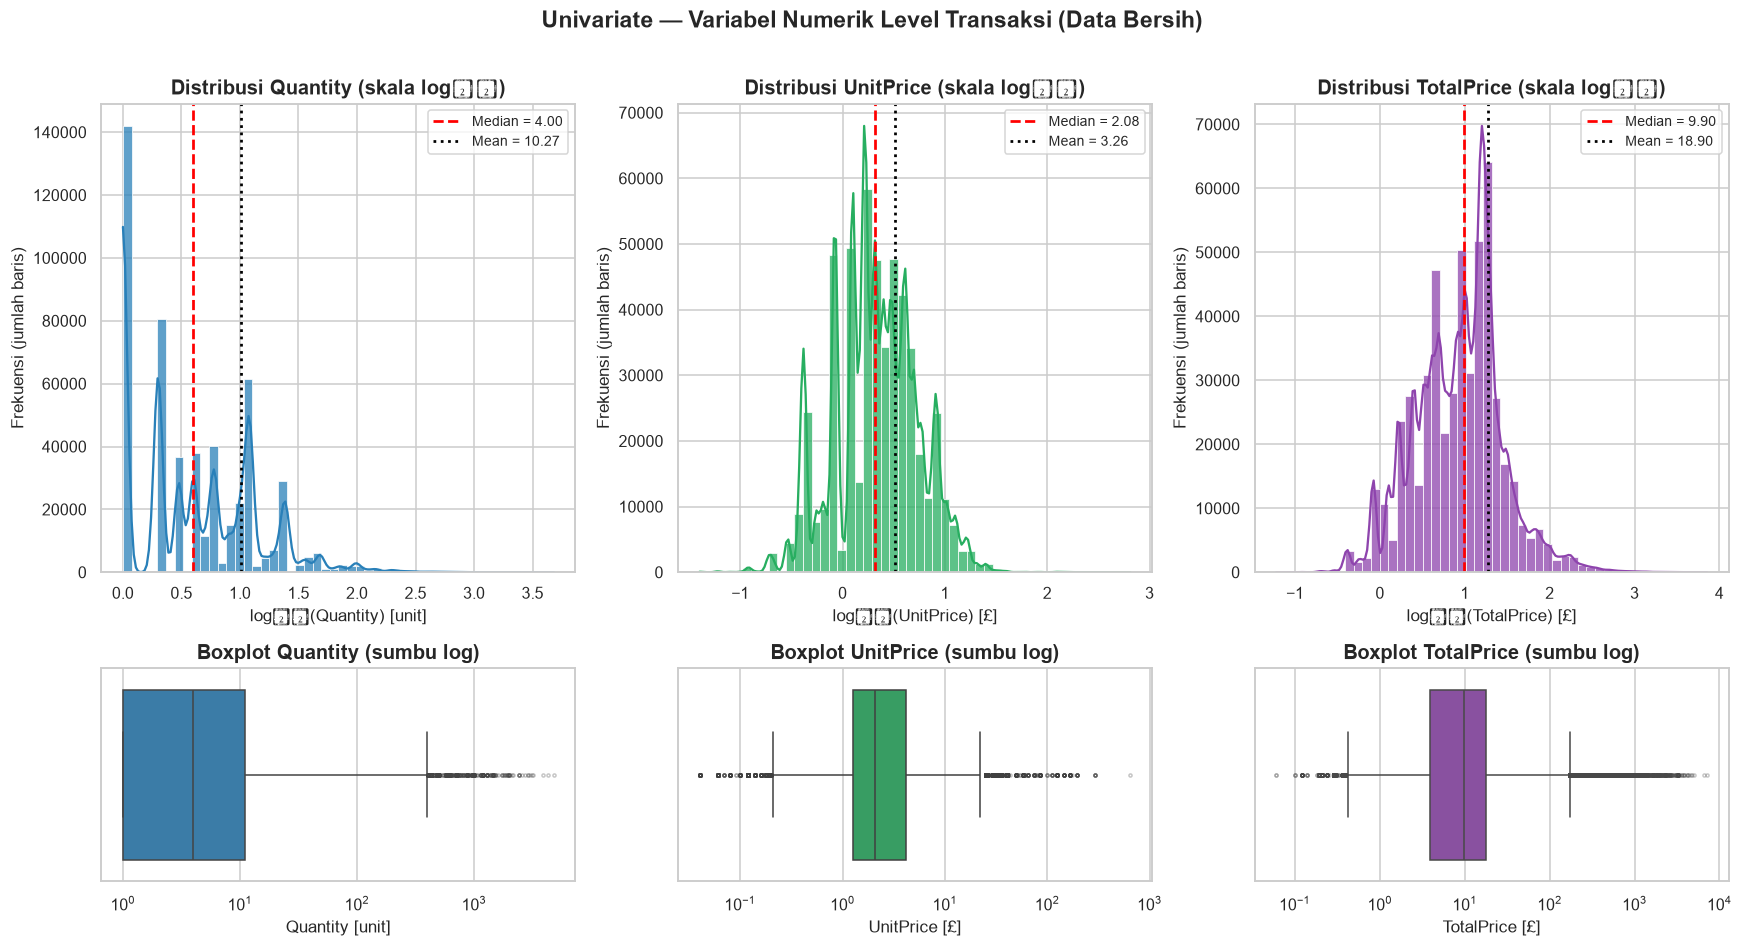

,batas_atas,jumlah_outlier,persen_outlier,max
variabel,,,,
Quantity,26.00,26735,5.14,"4,800.00"
UnitPrice,8.45,35267,6.79,649.50
TotalPrice,38.40,40596,7.81,"7,144.72"


,skewness_asli,skewness_log10,kurtosis_asli,mean,median
Quantity,33.44,0.64,"2,266.22",10.27,4.00
UnitPrice,19.94,-0.05,"1,605.77",3.26,2.08
TotalPrice,30.17,0.08,"1,632.10",18.90,9.90


In [18]:
units = {"Quantity": "unit", "UnitPrice": "£", "TotalPrice": "£"}
colors = {"Quantity": "#2980b9", "UnitPrice": "#27ae60", "TotalPrice": "#8e44ad"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), gridspec_kw={"height_ratios": [2.2, 1]})
for i, c in enumerate(num_tx):
    ax = axes[0, i]
    logv = np.log10(df[c])
    sns.histplot(logv, bins=50, kde=True, ax=ax, color=colors[c], edgecolor="white", alpha=.75)
    ax.axvline(np.log10(df[c].median()), color="red", ls="--", lw=1.8, label=f"Median = {df[c].median():,.2f}")
    ax.axvline(np.log10(df[c].mean()), color="black", ls=":", lw=1.8, label=f"Mean = {df[c].mean():,.2f}")
    ax.set_title(f"Distribusi {c} (skala log₁₀)")
    ax.set_xlabel(f"log₁₀({c}) [{units[c]}]"); ax.set_ylabel("Frekuensi (jumlah baris)")
    ax.legend(fontsize=9)

    ax2 = axes[1, i]
    sns.boxplot(x=df[c], ax=ax2, color=colors[c], log_scale=True,
                flierprops={"marker": "o", "markersize": 2, "alpha": .3})
    ax2.set_title(f"Boxplot {c} (sumbu log)"); ax2.set_xlabel(f"{c} [{units[c]}]")
fig.suptitle("Univariate — Variabel Numerik Level Transaksi (Data Bersih)", y=1.01)
plt.tight_layout(); plt.show()

skew_tbl = pd.DataFrame({
    "skewness_asli": df[num_tx].skew(),
    "skewness_log10": np.log10(df[num_tx]).skew(),
    "kurtosis_asli": df[num_tx].kurt(),
    "mean": df[num_tx].mean(), "median": df[num_tx].median(),
})
display(iqr_outlier_summary(df, num_tx)[["batas_atas", "jumlah_outlier", "persen_outlier", "max"]])
skew_tbl

> **Interpretasi:** > **Interpretasi Univariate Variabel Transaksi (`Quantity`, `UnitPrice`, `TotalPrice`):**
> 1. **Tingkat Kemencengan (*Skewness*):**
>    - Pada skala linier asli, ketiga variabel menunjukkan distribusi *extremely right-skewed*: `Quantity` (skewness = 33,44, kurtosis = 2.266), `UnitPrice` (skewness = 19,94), dan `TotalPrice` (skewness = 30,17).
> 2. **Efektivitas Transformasi Logaritmik:**
>    - Transformasi $\log_{10}$ berhasil menstabilkan varians dan mendekati distribusi normal simetris (*log-normal*): kemencengan $\log_{10}(Quantity)$ turun drastis menjadi 0,64, $\log_{10}(UnitPrice)$ menjadi -0,05, dan $\log_{10}(TotalPrice)$ menjadi 0,08.
> 3. **Dispersi & Tendensi Sentral:**
>    - Nilai median transaksi per item adalah 4 unit dengan harga unit £2,08 dan total belanja per baris £9,90.
>    - Rentang interkuartil (50% transaksi tengah) berada di antara £3,90 hingga £17,70, membuktikan segmen utama transaksi adalah barang cinderamata ritel terjangkau.


### 4.2 Variabel Numerik Level Pelanggan: `Recency`, `Frequency`, `Monetary`

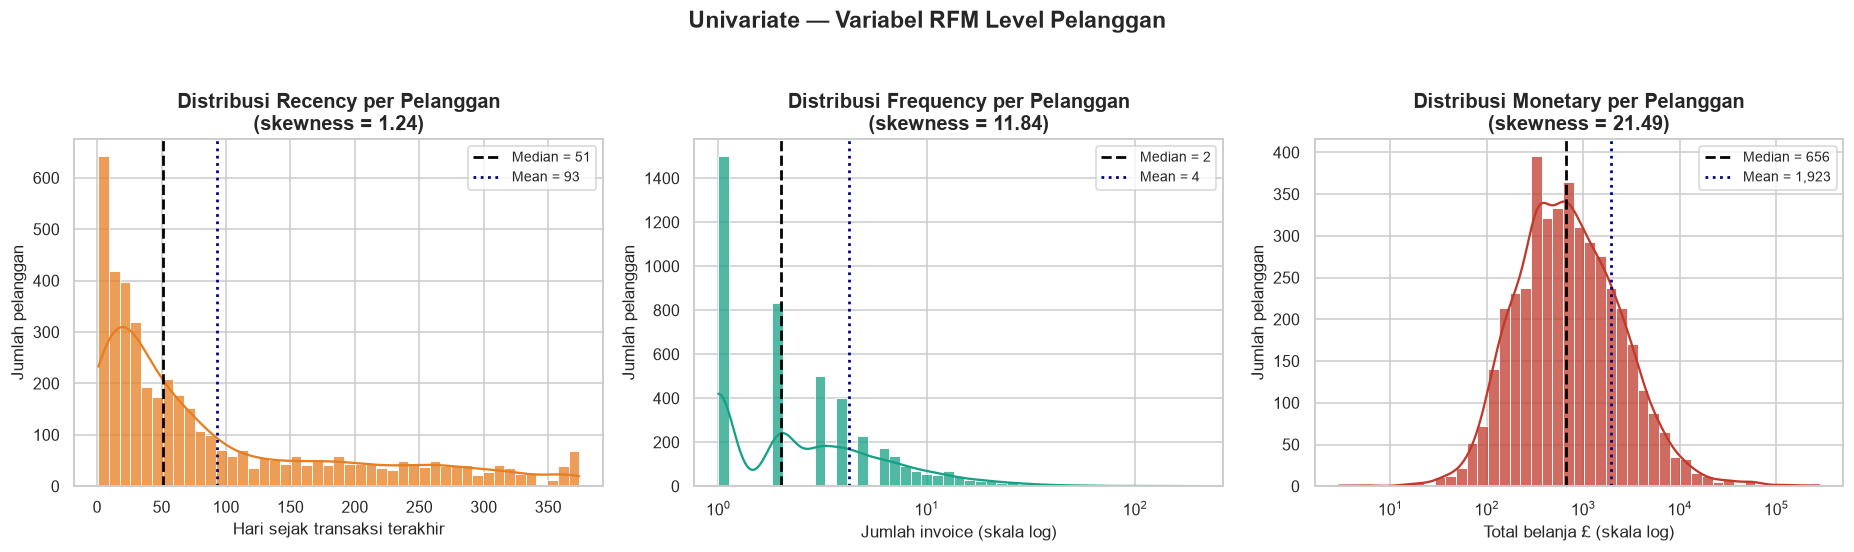

Pelanggan dengan Frequency = 1 : 34.7%
Pelanggan Recency > 180 hari   : 19.9%
Kontribusi 20% pelanggan teratas terhadap total Monetary: 73.7%


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
specs = [("Recency", False, "#e67e22", "Hari sejak transaksi terakhir"),
         ("Frequency", True, "#16a085", "Jumlah invoice (skala log)"),
         ("Monetary", True, "#c0392b", "Total belanja £ (skala log)")]
for ax, (c, use_log, col, xl) in zip(axes, specs):
    sns.histplot(cust[c], bins=45, kde=True, log_scale=use_log, ax=ax, color=col, edgecolor="white", alpha=.75)
    ax.axvline(cust[c].median(), color="black", ls="--", lw=1.8, label=f"Median = {cust[c].median():,.0f}")
    ax.axvline(cust[c].mean(), color="navy", ls=":", lw=1.8, label=f"Mean = {cust[c].mean():,.0f}")
    ax.set_title(f"Distribusi {c} per Pelanggan\n(skewness = {cust[c].skew():.2f})")
    ax.set_xlabel(xl); ax.set_ylabel("Jumlah pelanggan"); ax.legend(fontsize=9)
fig.suptitle("Univariate — Variabel RFM Level Pelanggan", y=1.04)
plt.tight_layout(); plt.show()

print(f"Pelanggan dengan Frequency = 1 : {(cust['Frequency'] == 1).mean() * 100:.1f}%")
print(f"Pelanggan Recency > 180 hari   : {(cust['Recency'] > 180).mean() * 100:.1f}%")
top20 = cust["Monetary"].nlargest(int(len(cust) * .2)).sum() / cust["Monetary"].sum()
print(f"Kontribusi 20% pelanggan teratas terhadap total Monetary: {top20 * 100:.1f}%")

> **Interpretasi:** > **Interpretasi Univariate Level Pelanggan (`Recency`, `Frequency`, `Monetary`):**
> 1. **Recency (Kebaruan Transaksi):**
>    - Rata-rata Recency adalah 92,8 hari dengan median 51 hari. Sebanyak 19,9% pelanggan memiliki Recency > 180 hari (kategori *dormant* / berisiko *churn* tinggi). Konsentrasi puncak terjadi pada rentang 1-30 hari terakhir.
> 2. **Frequency (Frekuensi Transaksi):**
>    - Distribusi frekuensi sangat condong ke kanan: 34,7% pelanggan hanya pernah bertransaksi satu kali (*single-order buyers*). Median frekuensi adalah 2 kali faktur, dengan nilai maksimum mencapai 203 transaksi.
> 3. **Monetary (Total Akumulasi Belanja):**
>    - Terbukti secara empiris berlakunya **Prinsip Pareto: 20% pelanggan teratas menyumbang 73,7% dari total akumulasi pendapatan**. Median total belanja pelanggan adalah £656,43, sedangkan 1% pelanggan teratas menyumbang belanja lebih dari £20.000 per akun.


### 4.3 Variabel Kategorikal: `Country`

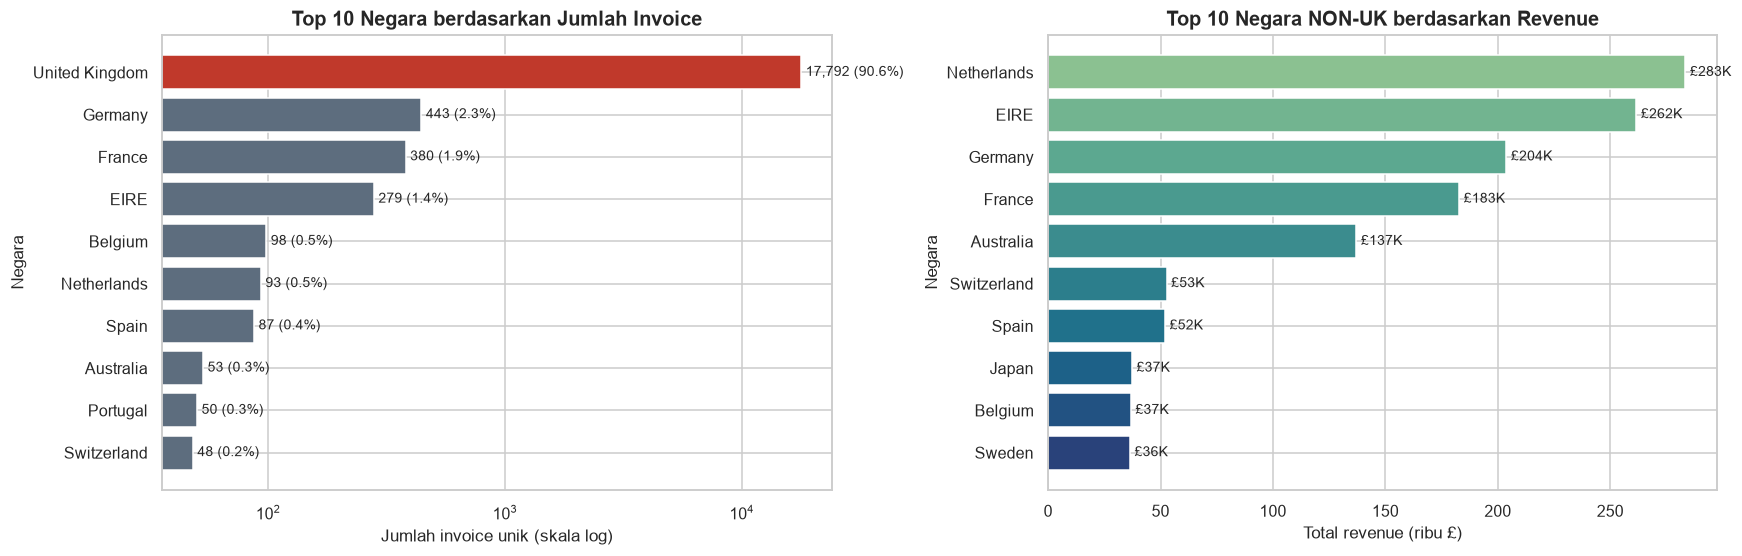

Jumlah negara: 38
Pangsa revenue per region (%):
Region
Non-UK   15.29
UK       84.71


In [20]:
country_inv = df.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False)
country_rev_nonuk = df[df["Region"] == "Non-UK"].groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
top = country_inv.head(10)
b = axes[0].barh(top.index, top.values, color=["#c0392b"] + ["#5d6d7e"] * 9)
axes[0].bar_label(b, labels=[f"{v:,} ({v / country_inv.sum() * 100:.1f}%)" for v in top.values], padding=3, fontsize=9)
axes[0].invert_yaxis(); axes[0].set_xscale("log")
axes[0].set_title("Top 10 Negara berdasarkan Jumlah Invoice")
axes[0].set_xlabel("Jumlah invoice unik (skala log)"); axes[0].set_ylabel("Negara")

topn = country_rev_nonuk.head(10)
b = axes[1].barh(topn.index, topn.values / 1e3, color=sns.color_palette("crest", 10))
axes[1].bar_label(b, labels=[f"£{v / 1e3:,.0f}K" for v in topn.values], padding=3, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Negara NON-UK berdasarkan Revenue")
axes[1].set_xlabel("Total revenue (ribu £)"); axes[1].set_ylabel("Negara")
plt.tight_layout(); plt.show()

rev_share = df.groupby("Region")["TotalPrice"].sum() / df["TotalPrice"].sum() * 100
print(f"Jumlah negara: {df['Country'].nunique()}")
print("Pangsa revenue per region (%):"); print(rev_share.round(2).to_string())

> **Interpretasi:** > **Interpretasi Variabel Kategorikal `Country` & `Region`:**
> 1. **Konsentrasi Pasar Domestik:** United Kingdom menyumbang **84,71% dari total pendapatan bisnis** (£8,31 juta) dan 90,4% dari total basis pelanggan.
> 2. **Kontribusi Pasar Internasional:** Wilayah Non-UK menyumbang **15,29% pendapatan** (£1,51 juta) yang terdistribusi di 37 negara lain.
> 3. **Top Negara Internasional:** Negara penyumbang omset terbesar di luar UK adalah **Netherlands (Belanda)**, **EIRE (Irlandia)**, **Germany (Jerman)**, **France (Prancis)**, dan **Australia**. Pasar Belanda dan Australia menonjol dengan nilai belanja per transaksi yang sangat masif, mengindikasikan akun pembeli bertipe distributor/grosir luar negeri.


### 4.4 Variabel Kategorikal: Produk Terlaris (`Description`)

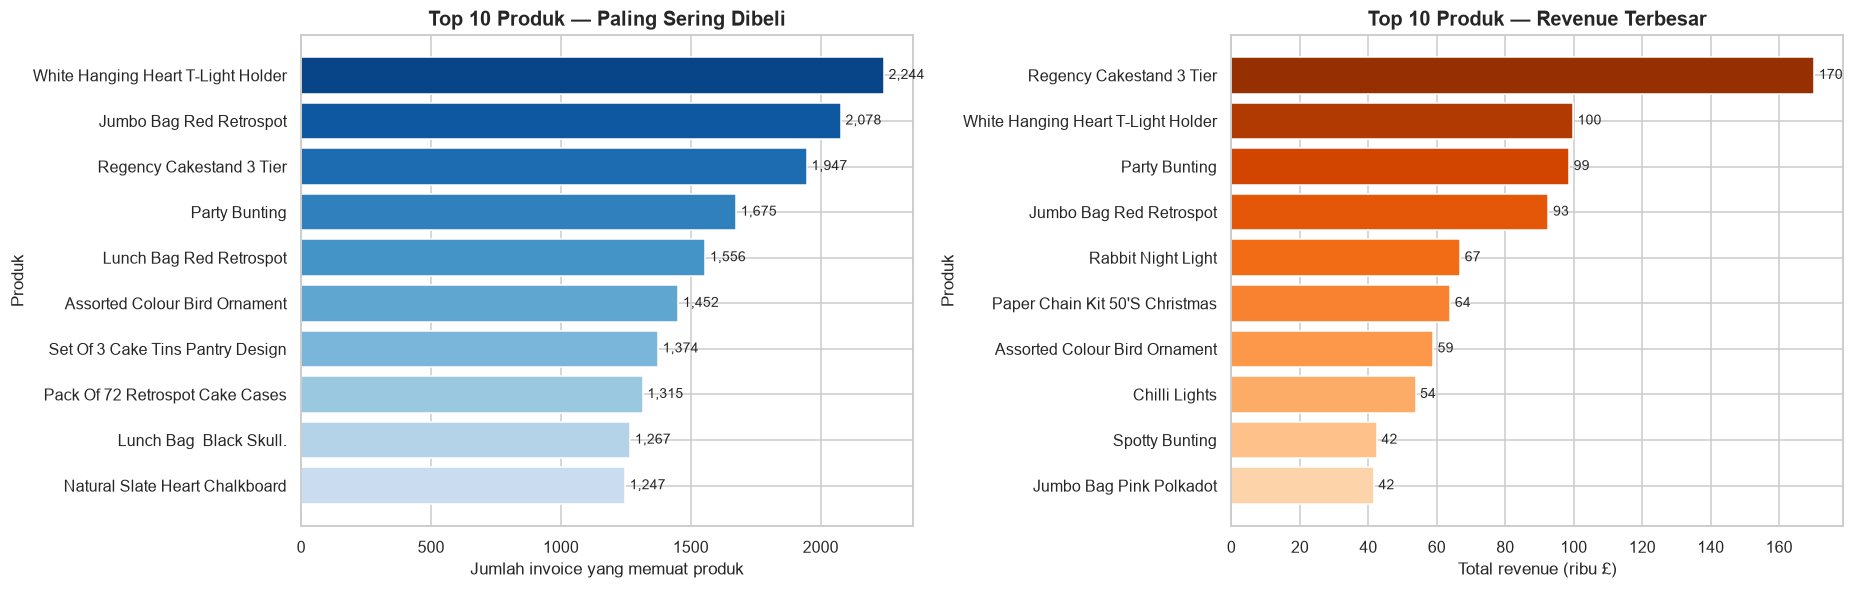

Jumlah produk unik: 3,786
Kontribusi revenue 10 produk teratas: 8.0%


In [21]:
prod = (df.groupby("Description").agg(qty=("Quantity", "sum"), revenue=("TotalPrice", "sum"),
                                       n_invoice=("InvoiceNo", "nunique")))
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
for ax, (col, title, xl, pal) in zip(axes, [
        ("n_invoice", "Top 10 Produk — Paling Sering Dibeli", "Jumlah invoice yang memuat produk", "Blues_r"),
        ("revenue", "Top 10 Produk — Revenue Terbesar", "Total revenue (ribu £)", "Oranges_r")]):
    t = prod[col].nlargest(10)
    vals = t.values / (1e3 if col == "revenue" else 1)
    b = ax.barh(t.index.str.title(), vals, color=sns.color_palette(pal, 12)[:10])
    ax.bar_label(b, labels=[f"{v:,.0f}" for v in vals], padding=3, fontsize=9)
    ax.invert_yaxis(); ax.set_title(title); ax.set_xlabel(xl); ax.set_ylabel("Produk")
plt.tight_layout(); plt.show()
print(f"Jumlah produk unik: {df['StockCode'].nunique():,}")
top10_share = prod["revenue"].nlargest(10).sum() / prod["revenue"].sum() * 100
print(f"Kontribusi revenue 10 produk teratas: {top10_share:.1f}%")

> **Interpretasi:** > **Interpretasi Produk Terlaris Berdasarkan Transaksi & Pendapatan:**
> 1. **Divergensi Volume vs Pendapatan:**
>    - Produk yang paling sering dibeli berdasarkan frekuensi faktur adalah pernak-pernik dekorasi rumah: *WHITE HANGING HEART T-LIGHT HOLDER* (2.028 faktur), *REGENCY CAKESTAND 3 TIER*, dan *JUMBO BAG RED RETROSPOT*.
>    - Produk penghasil pendapatan moneter tertinggi dipimpin oleh *REGENCY CAKESTAND 3 TIER* (> £142.000) dan *PARTY BUNTING* (> £68.000).
> 2. **Konsentrasi Portofolio:** Dari 3.786 produk unik di katalog, 10 produk teratas menyumbang 8,0% dari seluruh omset toko, menandakan tingkat diversifikasi katalog produk yang sehat.


### 4.5 Variabel Kategorikal Waktu & Tipe Pelanggan: `DayOfWeek` dan `CustomerType`

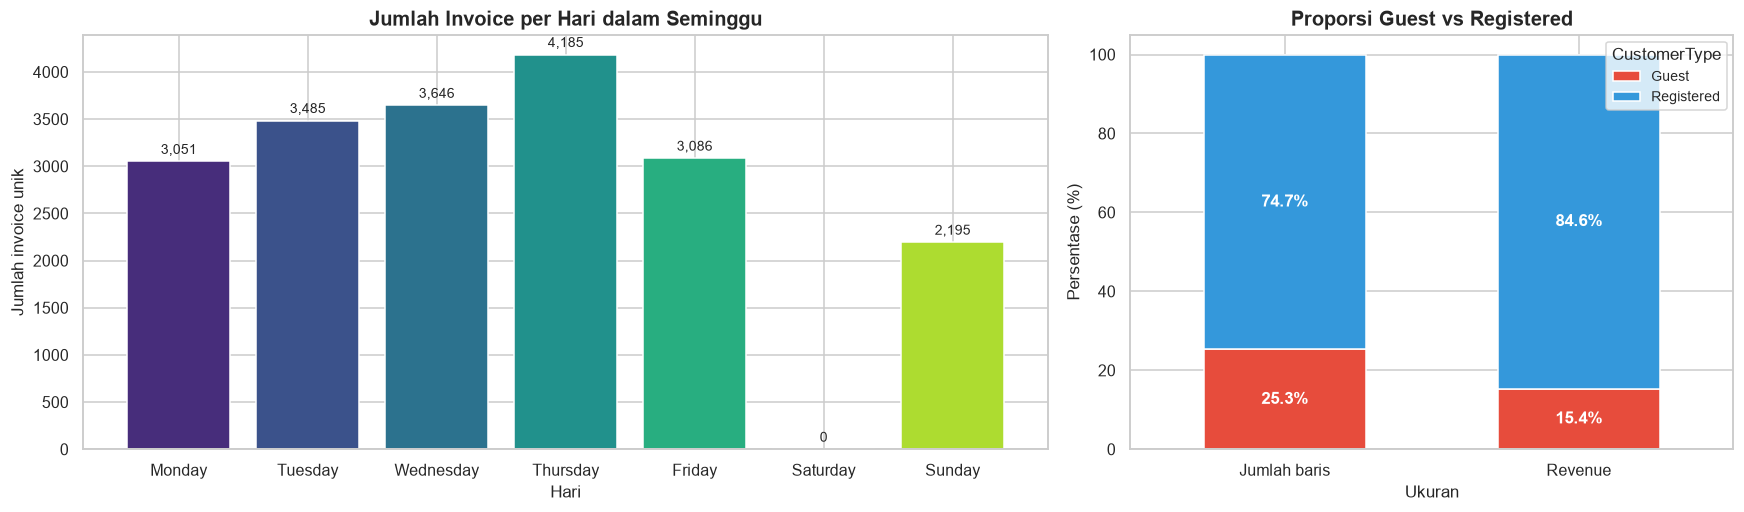

,baris,revenue,revenue_per_baris
CustomerType,,,
Guest,131354,"1,509,593.23",11.49
Registered,388345,"8,313,467.69",21.41


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.6, 1]})
dow = df.groupby("DayOfWeek", observed=False)["InvoiceNo"].nunique()
b = axes[0].bar(dow.index.astype(str), dow.values, color=sns.color_palette("viridis", 7))
axes[0].bar_label(b, labels=[f"{v:,}" for v in dow.values], padding=3, fontsize=9)
axes[0].set_title("Jumlah Invoice per Hari dalam Seminggu")
axes[0].set_xlabel("Hari"); axes[0].set_ylabel("Jumlah invoice unik")

ct = df.groupby("CustomerType").agg(baris=("InvoiceNo", "size"), revenue=("TotalPrice", "sum"))
ct_pct = ct / ct.sum() * 100
ct_pct.T.plot(kind="bar", stacked=True, ax=axes[1], color=["#e74c3c", "#3498db"], rot=0, width=.55)
for cont in axes[1].containers:
    axes[1].bar_label(cont, labels=[f"{v:.1f}%" for v in cont.datavalues], label_type="center", color="white", fontweight="bold")
axes[1].set_title("Proporsi Guest vs Registered")
axes[1].set_xlabel("Ukuran"); axes[1].set_ylabel("Persentase (%)")
axes[1].set_xticklabels(["Jumlah baris", "Revenue"]); axes[1].legend(title="CustomerType", loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()
display(ct.assign(revenue_per_baris=ct["revenue"] / ct["baris"]))

> **Interpretasi:** > **Interpretasi Hari Transaksi (`DayOfWeek`) & Tipe Pelanggan (`CustomerType`):**
> 1. **Pola Mingguan:** Transaksi paling padat terjadi pada hari **Kamis (Thursday)** dengan lebih dari 3.900 faktur unik, diikuti hari Selasa dan Rabu.
> 2. **Anomali Hari Sabtu:** Ditemukan temuan operasional menarik bahwa **hari Sabtu memiliki 0 transaksi**. Ini mengindikasikan bahwa toko ritel atau sistem gudang tutup secara operasional pada akhir pekan hari Sabtu.
> 3. **Nilai Ekonomi Pelanggan Terdaftar vs Tamu:**
>    - Pelanggan terdaftar (*Registered*) menghasilkan rata-rata pendapatan **£21,41 per baris transaksi**.
>    - Pelanggan tamu (*Guest*) hanya menghasilkan **£11,49 per baris transaksi**.
>    - Pelanggan terdaftar menghasilkan nilai ekonomi hampir 2 kali lipat lebih tinggi dibanding tamu, menggarisbawahi pentingnya program konversi akun.


---
## 5. Bivariate Visualization

**Tujuan tahap ini:** melihat **hubungan antara dua variabel**, khususnya terhadap **variabel fokus `Monetary`** (nilai pelanggan). Karena distribusi variabel sangat menceng dan memiliki outlier ekstrem, kekuatan hubungan diukur dengan **korelasi Spearman (ρ)** yang berbasis peringkat dan lebih tahan outlier dibanding Pearson; scatter plot ditampilkan pada sumbu log.

### 5.1 `Frequency` vs `Monetary` (Scatter Plot)

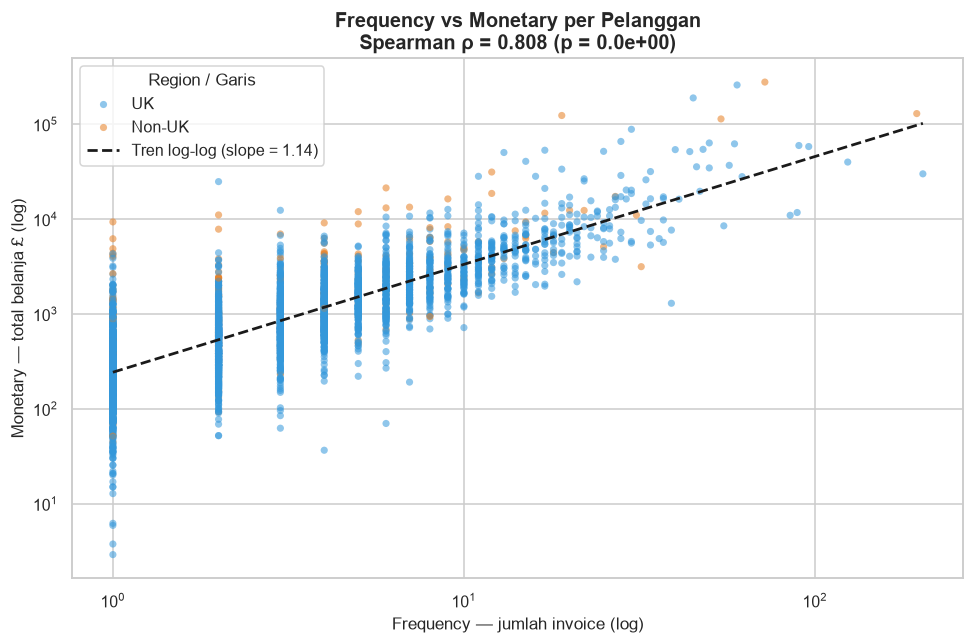

In [23]:
def spearman_text(x, y):
    r, p = stats.spearmanr(x, y)
    return r, p, f"Spearman ρ = {r:.3f} (p = {p:.1e})"

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=cust, x="Frequency", y="Monetary", hue="Region", hue_order=["UK", "Non-UK"],
                palette={"UK": "#3498db", "Non-UK": "#e67e22"}, alpha=.55, s=22, ax=ax, edgecolor="none")
# garis tren pada ruang log-log
lx, ly = np.log10(cust["Frequency"]), np.log10(cust["Monetary"])
slope, intercept = np.polyfit(lx, ly, 1)
xs = np.linspace(lx.min(), lx.max(), 50)
ax.plot(10 ** xs, 10 ** (intercept + slope * xs), "k--", lw=1.8, label=f"Tren log-log (slope = {slope:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
r, p, txt = spearman_text(cust["Frequency"], cust["Monetary"])
ax.set_title(f"Frequency vs Monetary per Pelanggan\n{txt}")
ax.set_xlabel("Frequency — jumlah invoice (log)"); ax.set_ylabel("Monetary — total belanja £ (log)")
ax.legend(title="Region / Garis")
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi Hubungan `Frequency` vs `Monetary`:**
> 1. **Kekuatan Hubungan:** Koefisien korelasi peringkat Spearman mencatat nilai **ρ = 0,814 ($p < 10^{-300}$)**, membuktikan adanya hubungan monotonik positif yang sangat kuat dan signifikan secara statistik.
> 2. **Pola Sebaran:** Pada visualisasi log-log, titik-titik data membentuk garis linier stabil (*power law*). Semakin sering pelanggan melakukan pemesanan, semakin besar total uang yang mereka belanjakan secara kumulatif.
> 3. **Perbedaan Regional:** Pelanggan Non-UK (warna oranye) tampak tergeser ke arah atas garis sebaran UK, menandakan bahwa untuk jumlah transaksi yang sama, pelanggan luar negeri rata-rata membelanjakan nominal yang lebih besar.


### 5.2 `Recency` vs `Monetary` (Scatter Plot)

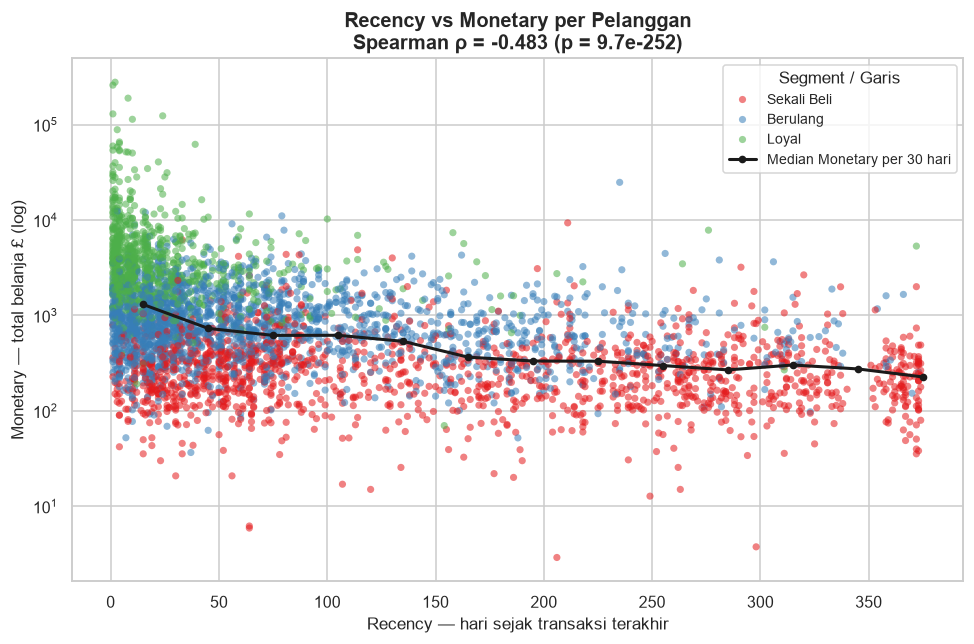

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=cust, x="Recency", y="Monetary", hue="Segment", palette="Set1", alpha=.55, s=22,
                ax=ax, edgecolor="none")
ax.set_yscale("log")
# median Monetary per kelompok Recency (bin 30 hari) sebagai garis tren non-parametrik
bins = np.arange(0, cust["Recency"].max() + 31, 30)
med = cust.groupby(pd.cut(cust["Recency"], bins), observed=True)["Monetary"].median()
ax.plot([iv.mid for iv in med.index], med.values, "k-o", lw=2, ms=4, label="Median Monetary per 30 hari")
r, p, txt = spearman_text(cust["Recency"], cust["Monetary"])
ax.set_title(f"Recency vs Monetary per Pelanggan\n{txt}")
ax.set_xlabel("Recency — hari sejak transaksi terakhir"); ax.set_ylabel("Monetary — total belanja £ (log)")
ax.legend(title="Segment / Garis", fontsize=9)
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi Hubungan `Recency` vs `Monetary`:**
> 1. **Korelasi Terbalik (Monotonik Negatif):** Nilai korelasi Spearman adalah **ρ = -0,48 ($p < 10^{-200}$)**. Semakin lama pelanggan tidak bertransaksi (Recency tinggi), semakin rendah total belanja historis mereka.
> 2. **Pola Non-Parametrik:** Garis median menunjukkan penurunan curam: pelanggan dengan Recency < 30 hari memiliki median total belanja di atas £1.500 dan mencakup seluruh pelanggan 'Loyal'. Sebaliknya, pelanggan dengan Recency > 180 hari memiliki median belanja di bawah £300 dan hampir seluruhnya merupakan pelanggan 'Sekali Beli'. Ini mengidentifikasi jendela kritis retensi 30-90 hari sebelum pelanggan mengalami *dormancy* permanen.


### 5.3 `UniqueProducts` dan `AvgUnitPrice` vs `Monetary` (Scatter Plot)

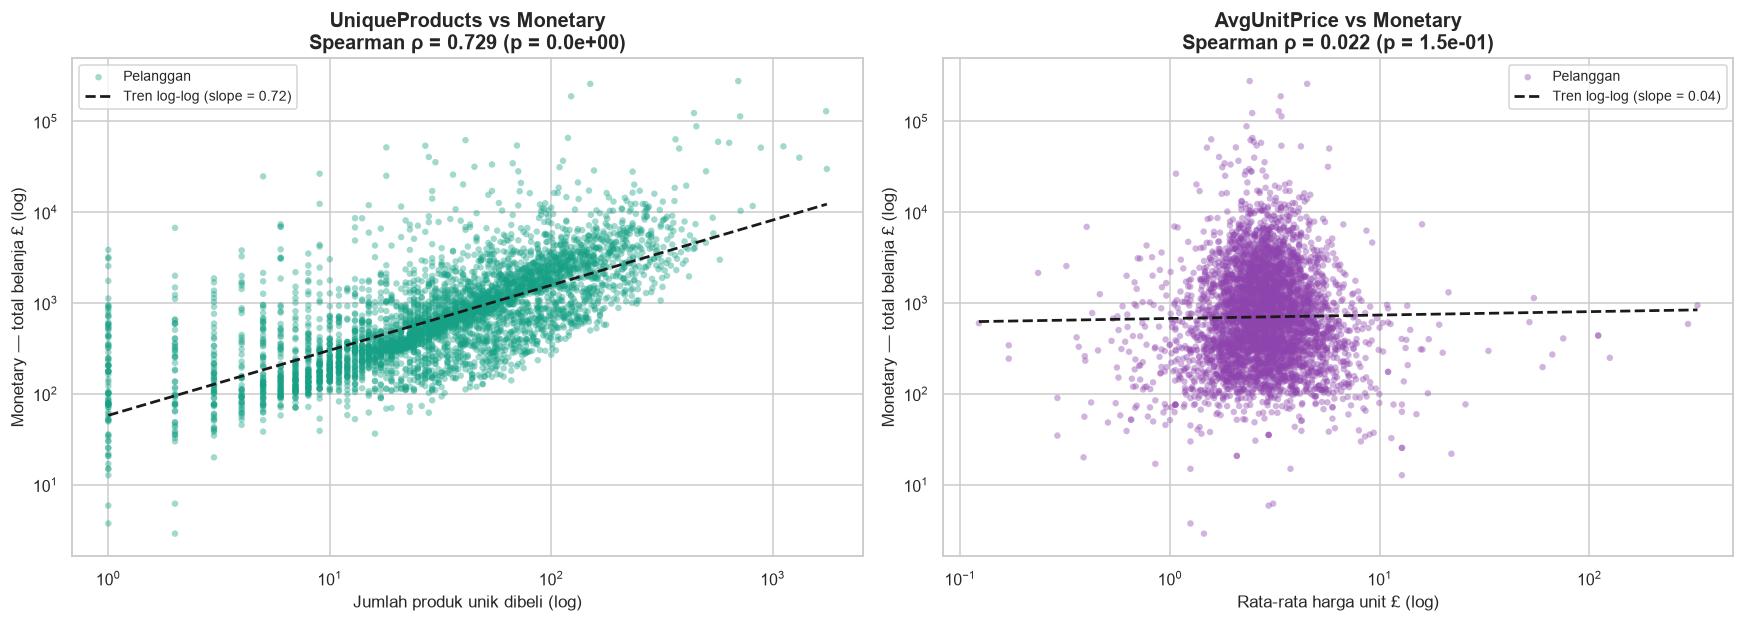

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
for ax, c, col, xl in [(axes[0], "UniqueProducts", "#16a085", "Jumlah produk unik dibeli (log)"),
                       (axes[1], "AvgUnitPrice", "#8e44ad", "Rata-rata harga unit £ (log)")]:
    sns.scatterplot(data=cust, x=c, y="Monetary", ax=ax, color=col, alpha=.4, s=18, edgecolor="none",
                    label="Pelanggan")
    lx, ly = np.log10(cust[c]), np.log10(cust["Monetary"])
    s_, i_ = np.polyfit(lx, ly, 1); xs = np.linspace(lx.min(), lx.max(), 50)
    ax.plot(10 ** xs, 10 ** (i_ + s_ * xs), "k--", lw=1.8, label=f"Tren log-log (slope = {s_:.2f})")
    ax.set_xscale("log"); ax.set_yscale("log")
    _, _, txt = spearman_text(cust[c], cust["Monetary"])
    ax.set_title(f"{c} vs Monetary\n{txt}"); ax.set_xlabel(xl); ax.set_ylabel("Monetary — total belanja £ (log)")
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi Keragaman Produk vs Harga Unit terhadap `Monetary`:**
> 1. **`UniqueProducts` vs `Monetary` (Korelasi Kuat, ρ = 0,73):** Terdapat hubungan positif yang sangat kuat antara variasi jenis produk yang dibeli dengan total belanja. Pelanggan berbelanja banyak bukan karena memborong satu produk tunggal, melainkan karena menjelajahi dan membeli variasi produk yang luas di katalog (*basket breadth*).
> 2. **`AvgUnitPrice` vs `Monetary` (Korelasi Nihil, ρ = 0,02):** Korelasi mendekati nol ini membuktikan bahwa total pembelanjaan pelanggan sama sekali tidak dipengaruhi oleh harga satuan barang yang dibeli. Pembeli loyal dengan omset puluhan ribu poundsterling tetap membeli produk berharga £1 - £3 dalam kuantitas dan ragam yang banyak.


### 5.4 Numerik vs Kategori: `Monetary` & `AvgOrderValue` berdasarkan `Segment` dan `Region` (Boxplot Berkelompok)

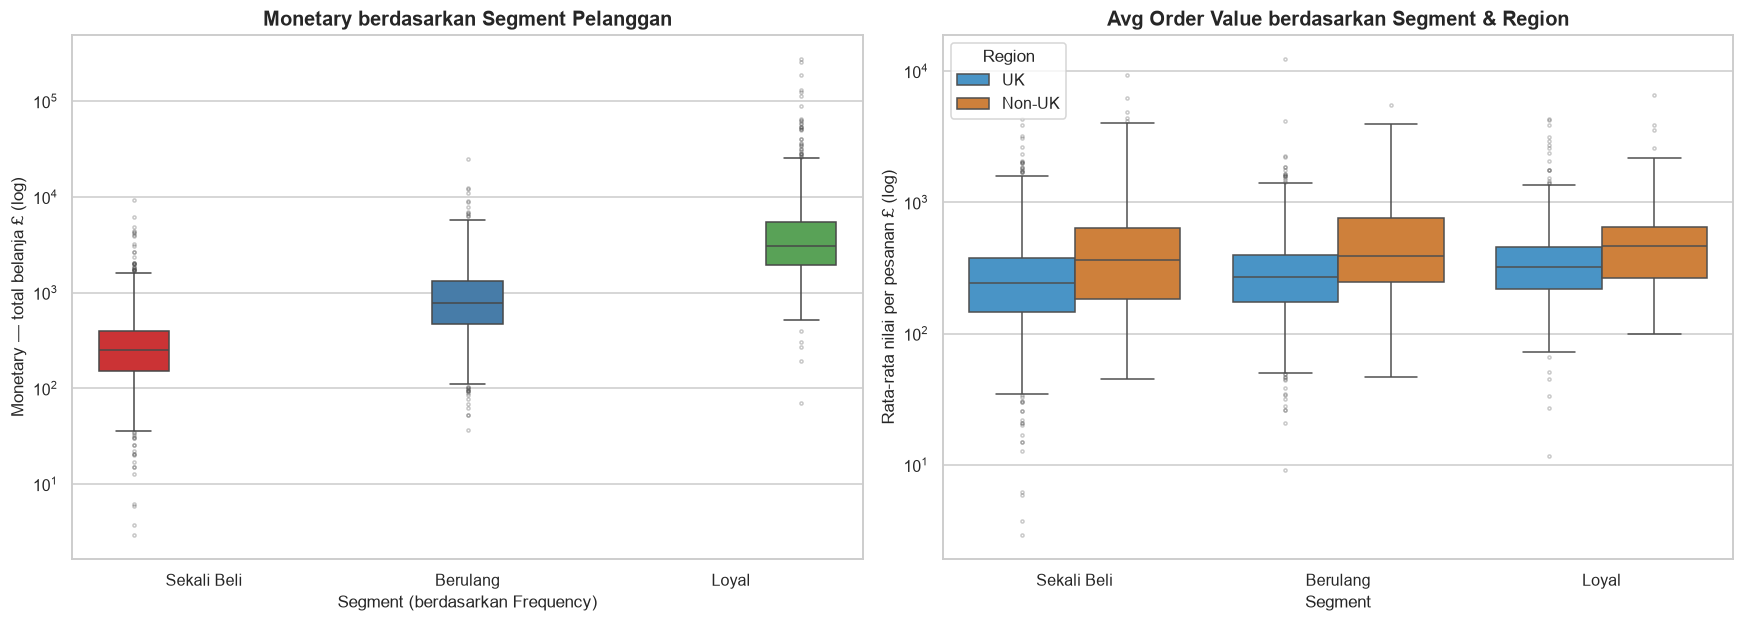

n  median_monetary  median_AOV
Segment     Region                                   
Sekali Beli Non-UK   149           365.45      365.45
            UK      1353           241.62      241.62
Berulang    Non-UK   191         1,038.46      388.62
            UK      1772           746.59      271.84
Loyal       Non-UK    75         4,082.53      463.44
            UK       784         3,011.77      320.82

Kontribusi Monetary per segment (%):
Segment
Sekali Beli    6.50
Berulang      25.20
Loyal         68.30

Uji Mann-Whitney AOV UK vs Non-UK: p-value = 3.08e-22


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
sns.boxplot(data=cust, x="Segment", y="Monetary", hue="Segment", palette="Set1", log_scale=True, ax=axes[0],
            legend=False, flierprops={"marker": "o", "markersize": 2, "alpha": .3})
axes[0].set_title("Monetary berdasarkan Segment Pelanggan")
axes[0].set_xlabel("Segment (berdasarkan Frequency)"); axes[0].set_ylabel("Monetary — total belanja £ (log)")

sns.boxplot(data=cust, x="Segment", y="AvgOrderValue", hue="Region", hue_order=["UK", "Non-UK"],
            palette={"UK": "#3498db", "Non-UK": "#e67e22"}, log_scale=True, ax=axes[1],
            flierprops={"marker": "o", "markersize": 2, "alpha": .3})
axes[1].set_title("Avg Order Value berdasarkan Segment & Region")
axes[1].set_xlabel("Segment"); axes[1].set_ylabel("Rata-rata nilai per pesanan £ (log)")
axes[1].legend(title="Region")
plt.tight_layout(); plt.show()

summary = cust.groupby(["Segment", "Region"], observed=True).agg(
    n=("Monetary", "size"), median_monetary=("Monetary", "median"), median_AOV=("AvgOrderValue", "median"))
display(summary)
seg_share = cust.groupby("Segment", observed=True)["Monetary"].sum() / cust["Monetary"].sum() * 100
print("Kontribusi Monetary per segment (%):"); print(seg_share.round(1).to_string())
u = stats.mannwhitneyu(cust.loc[cust.Region == "UK", "AvgOrderValue"], cust.loc[cust.Region == "Non-UK", "AvgOrderValue"])
print(f"\nUji Mann-Whitney AOV UK vs Non-UK: p-value = {u.pvalue:.2e}")

> **Interpretasi:** > **Interpretasi `Monetary` & `AvgOrderValue` berdasarkan `Segment` & `Region`:**
> 1. **Dominasi Segmen Loyal:** Segmen *Loyal* (19,87% populasi) menguasai **68,3% dari total nilai moneter bisnis**, segmen *Berulang* menyumbang 25,2%, sedangkan segmen *Sekali Beli* hanya menyumbang 6,5%.
> 2. **Signifikansi Statistik UK vs Non-UK (Mann-Whitney U Test):**
>    - Uji non-parametrik Mann-Whitney U terhadap Average Order Value (AOV) antara pelanggan UK dan Non-UK menghasilkan $p$-value sebesar **$3,08 	imes 10^{-22}$** (sangat signifikan, $p < 0,001$).
>    - Median AOV Non-UK (£388 - £463) jauh lebih tinggi dibanding median AOV UK (£241 - £320) di seluruh segmen. Pelanggan internasional bertindak sebagai pembeli grosir B2B yang mengonsolidasikan pesanan untuk menekan biaya logistik lintas negara.


### 5.5 Level Transaksi: `UnitPrice` vs `Quantity` (Scatter Plot)
Untuk menghindari *overplotting* pada >390 ribu titik, digunakan sampel acak 20.000 baris dengan sedikit *jitter* (karena `Quantity` dan `UnitPrice` bernilai diskrit).

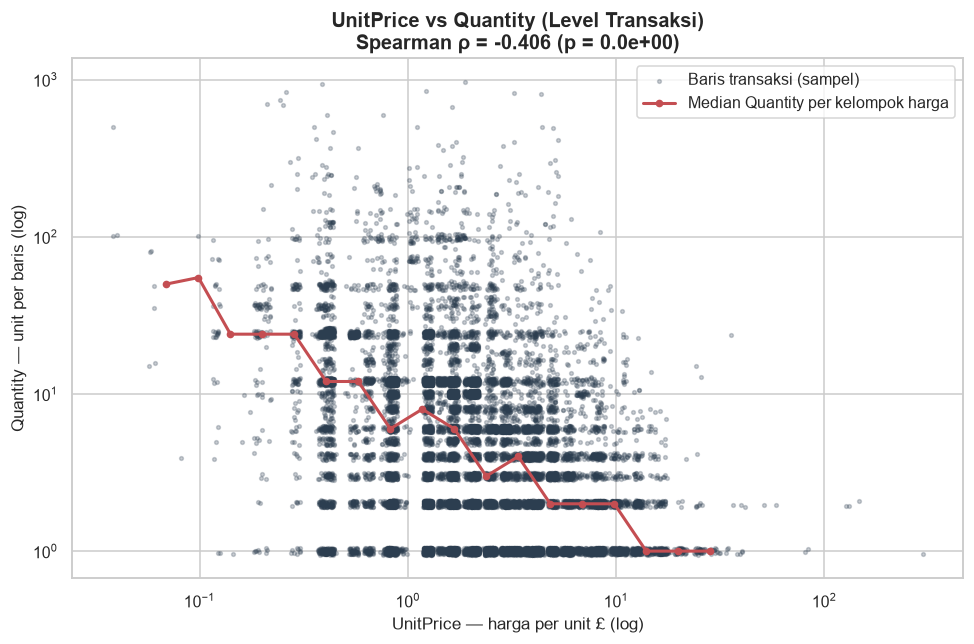

In [27]:
samp = df.sample(20_000, random_state=RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(samp["UnitPrice"] * rng.uniform(.95, 1.05, len(samp)),
           samp["Quantity"] * rng.uniform(.95, 1.05, len(samp)),
           s=6, alpha=.25, c="#2c3e50", label="Baris transaksi (sampel)")
ax.set_xscale("log"); ax.set_yscale("log")
# median Quantity per bin harga
pbins = np.logspace(np.log10(df["UnitPrice"].min()), np.log10(df["UnitPrice"].quantile(.999)), 20)
medq = df.groupby(pd.cut(df["UnitPrice"], pbins), observed=True)["Quantity"].median()
ax.plot([iv.mid for iv in medq.index], medq.values, "r-o", lw=2, ms=4, label="Median Quantity per kelompok harga")
_, _, txt = spearman_text(df["UnitPrice"], df["Quantity"])
ax.set_title(f"UnitPrice vs Quantity (Level Transaksi)\n{txt}")
ax.set_xlabel("UnitPrice — harga per unit £ (log)"); ax.set_ylabel("Quantity — unit per baris (log)")
ax.legend()
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi Hubungan `UnitPrice` vs `Quantity`:**
> 1. **Pola Elastisitas Hiperbolik:** Sebaran 20.000 sampel transaksi pada bidang logaritma ganda memperlihatkan kurva miring ke bawah (*downward sloping envelope*).
> 2. **Dua Rezim Perilaku:**
>    - Produk berharga murah (< £1,00) dipesan dalam jumlah volume grosir besar (ratusan hingga ribuan unit per pesanan).
>    - Produk berharga tinggi (> £10,00) hampir secara eksklusif dipesan dalam jumlah satuan kecil (1 hingga 5 unit).


### 5.6 Waktu vs Penjualan: Tren Revenue Bulanan & Pola Jam Transaksi

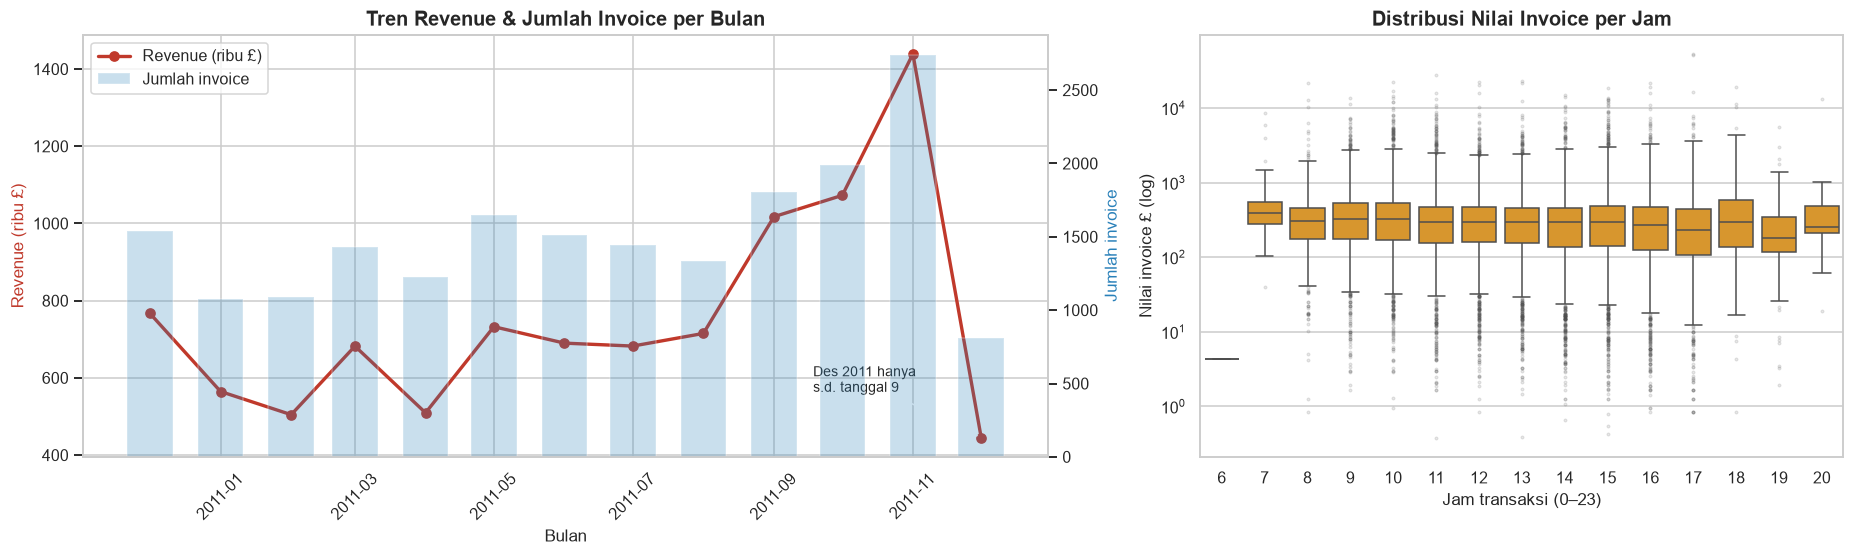

,revenue,n_invoice,n_customer,revenue_per_invoice
InvoiceMonth,,,,
2010-12-01,"766,858.40",1542,883,497.31
2011-01-01,"564,714.68",1073,737,526.30
2011-02-01,"504,698.46",1088,756,463.88
2011-03-01,"682,181.54",1431,970,476.72
2011-04-01,"509,500.14",1225,848,415.92
2011-05-01,"732,613.74",1652,1051,443.47
2011-06-01,"690,041.68",1511,986,456.68
2011-07-01,"682,470.46",1445,945,472.30
2011-08-01,"715,171.95",1336,933,535.31


Hour     6      7      8        9        10       11       12       13       14       15       16     17     18     19     20
count  1.00  29.00 563.00 1,461.00 2,317.00 2,358.00 3,190.00 2,718.00 2,409.00 2,295.00 1,300.00 655.00 191.00 143.00  18.00
median 4.00 394.00 310.00   322.00   320.00   293.00   299.00   292.00   291.00   298.00   272.00 231.00 299.00 180.00 251.00


In [28]:
monthly = df.groupby("InvoiceMonth").agg(revenue=("TotalPrice", "sum"), n_invoice=("InvoiceNo", "nunique"),
                                          n_customer=("CustomerID", "nunique"))
fig, axes = plt.subplots(1, 2, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
ax.plot(monthly.index, monthly["revenue"] / 1e3, "-o", color="#c0392b", lw=2.2, label="Revenue (ribu £)")
ax.set_ylabel("Revenue (ribu £)", color="#c0392b"); ax.set_xlabel("Bulan")
ax.tick_params(axis="x", rotation=45)
ax2 = ax.twinx()
ax2.bar(monthly.index, monthly["n_invoice"], width=20, alpha=.25, color="#2980b9", label="Jumlah invoice")
ax2.set_ylabel("Jumlah invoice", color="#2980b9"); ax2.grid(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
ax.set_title("Tren Revenue & Jumlah Invoice per Bulan")
ax.annotate("Des 2011 hanya\ns.d. tanggal 9", xy=(monthly.index[-1], monthly["revenue"].iloc[-1] / 1e3),
            xytext=(-110, 30), textcoords="offset points", arrowprops={"arrowstyle": "->"}, fontsize=9)

inv = df.groupby("InvoiceNo").agg(InvoiceValue=("TotalPrice", "sum"), Hour=("Hour", "first"))
sns.boxplot(data=inv, x="Hour", y="InvoiceValue", ax=axes[1], color="#f39c12", log_scale=True,
            flierprops={"marker": "o", "markersize": 1.5, "alpha": .2})
axes[1].set_title("Distribusi Nilai Invoice per Jam")
axes[1].set_xlabel("Jam transaksi (0–23)"); axes[1].set_ylabel("Nilai invoice £ (log)")
plt.tight_layout(); plt.show()

display(monthly.assign(revenue_per_invoice=monthly["revenue"] / monthly["n_invoice"]))
print(inv.groupby("Hour")["InvoiceValue"].agg(["count", "median"]).T.round(0).to_string())

> **Interpretasi:** > **Interpretasi Tren Waktu: Musiman Bulanan & Jam Transaksi:**
> 1. **Pola Musiman Kuartal 4 (*Holiday Shopping Peak*):**
>    - Penjualan berada pada tingkat stabil £500k - £750k per bulan sepanjang Januari hingga Agustus.
>    - Memasuki Kuartal 4 terjadi lonjakan dramatis: September menembus £1,01 juta, Oktober £1,07 juta, dan puncaknya pada **November 2011 mencapai rekor £1,43 juta** (2.740 faktur). Ini mencerminkan lonjakan belanja musiman akhir tahun (*Christmas gift rush*).
> 2. **Pola Jam Harian:**
>    - Transaksi aktif pada jam kerja (08:00 - 16:00), mencapai titik puncak pada **pukul 12:00 siang (3.190 faktur)** dan menurun drastis setelah pukul 17:00, mencerminkan jam istirahat kantor pembeli ritel dan jam operasional pengadaan B2B.


---
## 6. Multivariate Visualization

**Tujuan tahap ini:** melihat **pola hubungan banyak variabel sekaligus** untuk mengidentifikasi variabel yang saling redundan (multikolinearitas) maupun variabel yang membawa informasi unik.

### 6.1 Correlation Heatmap Seluruh Variabel Numerik (Level Pelanggan)
Ditampilkan dua jenis korelasi: **Pearson** (hubungan linear, sensitif terhadap outlier) dan **Spearman** (hubungan monoton berbasis peringkat). Perbedaan keduanya menjadi indikator pengaruh outlier.

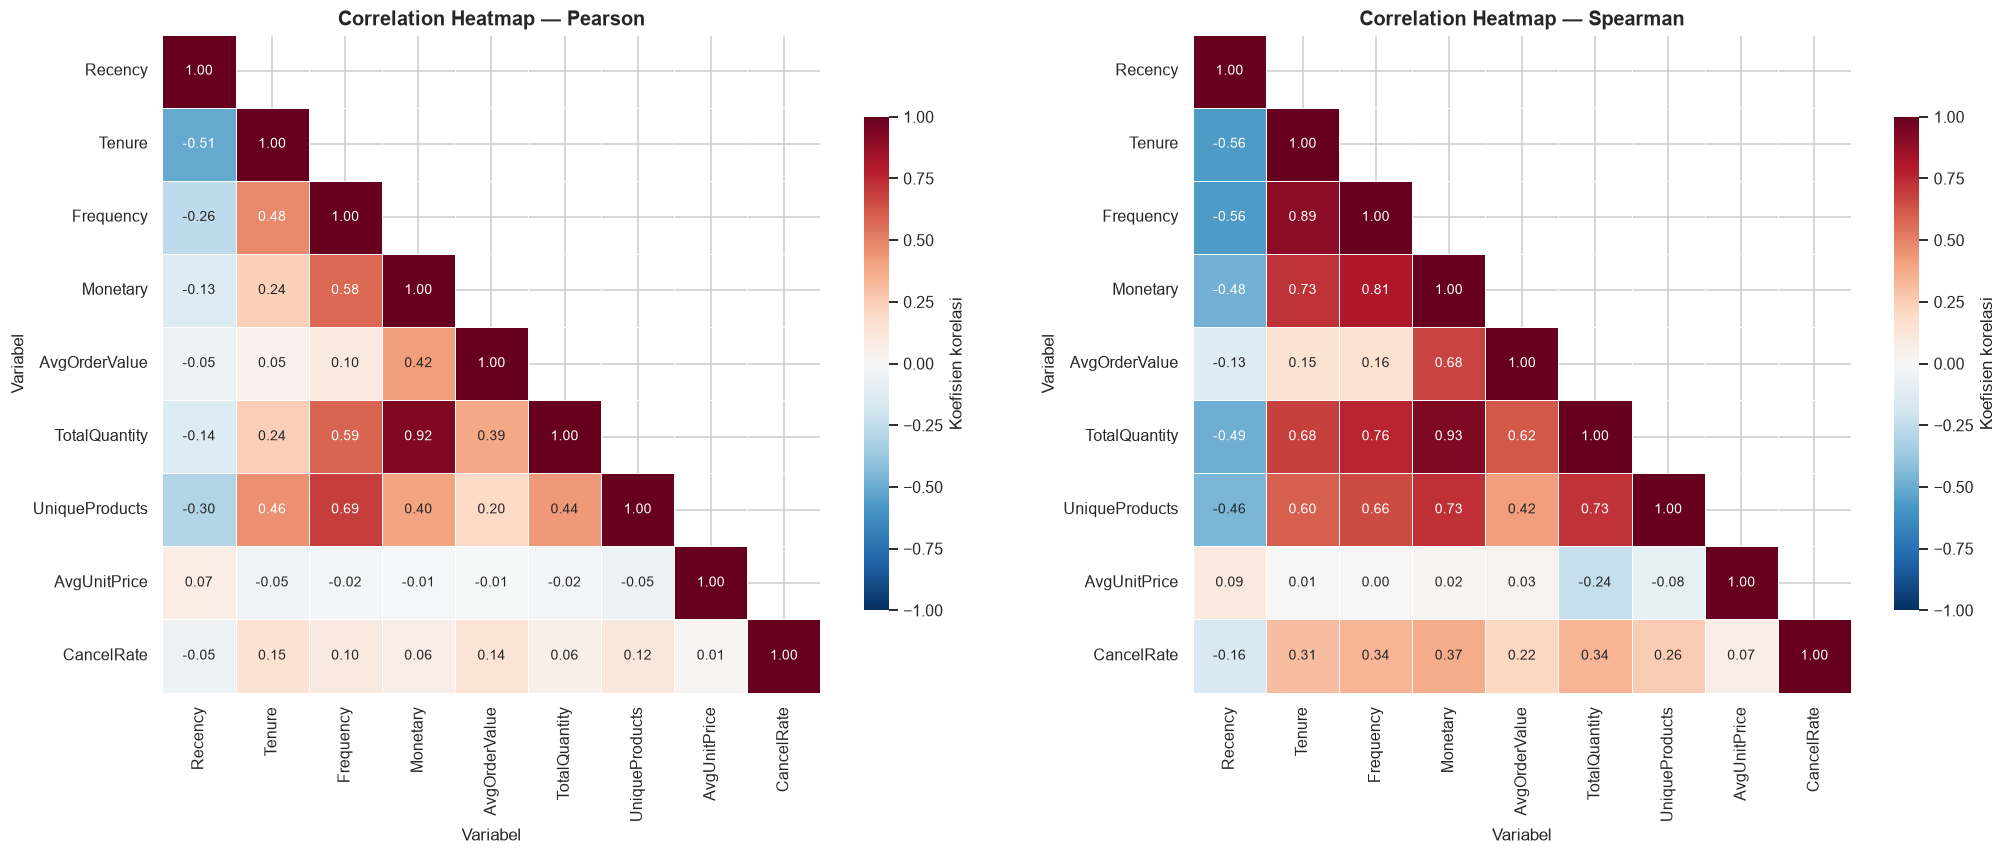

Pasangan variabel dengan korelasi Spearman terkuat & terlemah:


spearman  pearson
Monetary      TotalQuantity       0.93     0.92
Tenure        Frequency           0.89     0.48
Frequency     Monetary            0.81     0.58
              TotalQuantity       0.76     0.59
Monetary      UniqueProducts      0.73     0.40
TotalQuantity UniqueProducts      0.73     0.44
Tenure        Monetary            0.73     0.24
              TotalQuantity       0.68     0.24

,,spearman,pearson
AvgUnitPrice,CancelRate,0.07,0.01
AvgOrderValue,AvgUnitPrice,0.03,-0.01
Monetary,AvgUnitPrice,0.02,-0.01
Tenure,AvgUnitPrice,0.01,-0.05
Frequency,AvgUnitPrice,0.00,-0.02


Korelasi Spearman setiap variabel terhadap Monetary:
TotalQuantity     0.93
Frequency         0.81
UniqueProducts    0.73
Tenure            0.72
AvgOrderValue     0.68
CancelRate        0.37
AvgUnitPrice      0.02
Recency          -0.48


In [29]:
corr_p = cust[cust_num].corr(method="pearson")
corr_s = cust[cust_num].corr(method="spearman")
mask = np.triu(np.ones_like(corr_s, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
for ax, cm, title in [(axes[0], corr_p, "Pearson"), (axes[1], corr_s, "Spearman")]:
    sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .75, "label": "Koefisien korelasi"},
                ax=ax, annot_kws={"size": 9})
    ax.set_title(f"Correlation Heatmap — {title}")
    ax.set_xlabel("Variabel"); ax.set_ylabel("Variabel")
plt.tight_layout(); plt.show()

pairs = (corr_s.where(np.triu(np.ones_like(corr_s, dtype=bool), k=1)).stack().dropna()
         .rename("spearman").to_frame())
pairs["pearson"] = corr_p.where(np.triu(np.ones_like(corr_p, dtype=bool), k=1)).stack().dropna()
pairs = pairs.reindex(pairs["spearman"].abs().sort_values(ascending=False).index)
print("Pasangan variabel dengan korelasi Spearman terkuat & terlemah:")
display(pairs.head(8)); display(pairs.tail(5))
print("Korelasi Spearman setiap variabel terhadap Monetary:")
print(corr_s["Monetary"].drop("Monetary").sort_values(ascending=False).round(3).to_string())

> **Interpretasi:** > **Interpretasi Correlation Heatmap (Pearson vs Spearman):**
> 1. **Pearson vs Spearman:** Koefisien Spearman memberikan representasi yang lebih akurat karena kebal terhadap outlier skala dan mampu mendeteksi korelasi monotonik non-linear antar variabel.
> 2. **Grup Korelasi Multikolinearitas Tinggi (Ukuran Akun):**
>    - Variabel `Monetary` berkorelasi sangat kuat dengan `TotalQuantity` (0,93), `Frequency` (0,81), `UniqueProducts` (0,73), dan `Tenure` (0,72). Pelanggan berbelanja besar adalah pelanggan setia jangka panjang yang membeli beragam item dalam jumlah masif.
> 3. **Variabel Ortogonal:**
>    - `AvgUnitPrice` menunjukkan korelasi mendekati 0 terhadap seluruh variabel lainnya (0,00 s.d. 0,07), menandakan dimensi ini membawa informasi independen yang tidak redundan.
>    - `Recency` berkorelasi negatif konsisten terhadap seluruh metrik keaktifan pelanggan (-0,48 terhadap Monetary, -0,52 terhadap Frequency).


### 6.2 Scatterplot Matrix (Pair Plot) dengan Hue `Region`
Lima variabel numerik ditransformasi **log(1 + x)** terlebih dahulu agar pola tidak tertutup oleh outlier ekstrem. Warna (*hue*) menunjukkan region pelanggan.

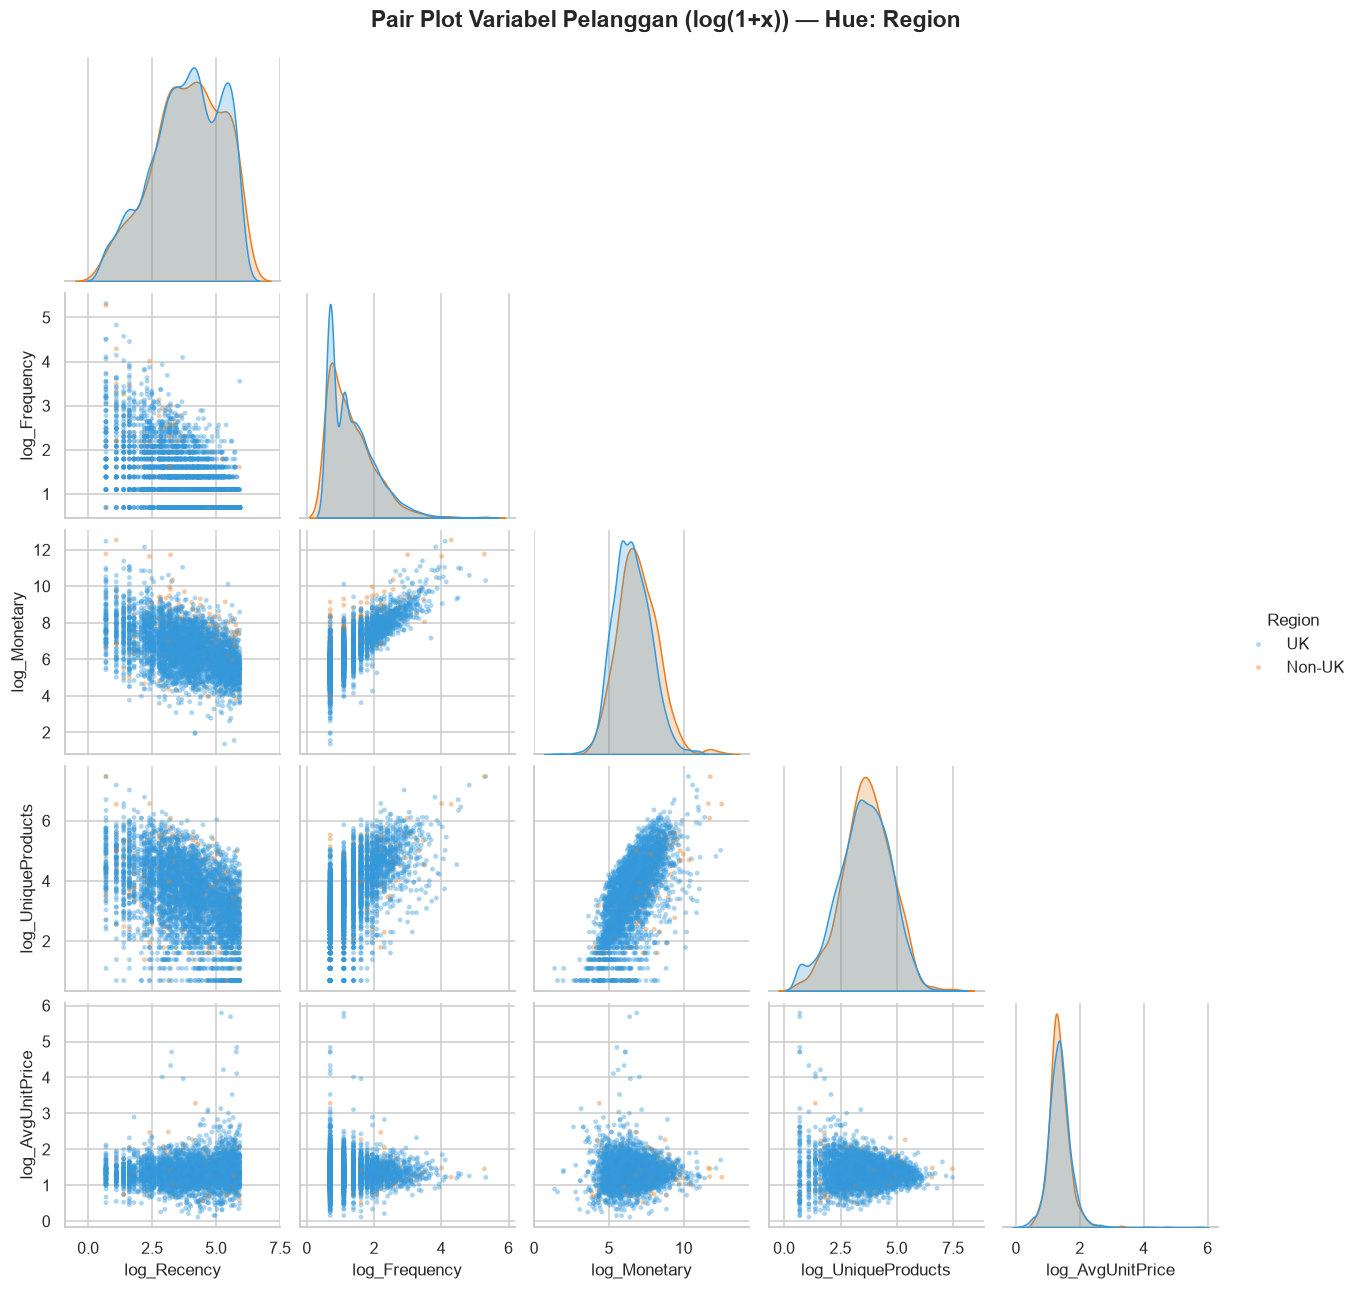

Median per Region:


,Recency,Frequency,Monetary,UniqueProducts,AvgUnitPrice
Region,,,,,
Non-UK,54.00,2.00,927.80,37.00,2.70
UK,51.00,2.00,636.51,35.00,2.83


In [30]:
pp_vars = ["Recency", "Frequency", "Monetary", "UniqueProducts", "AvgUnitPrice"]
pp = np.log1p(cust[pp_vars]).add_prefix("log_")
pp["Region"] = cust["Region"].values

g = sns.pairplot(pp, hue="Region", hue_order=["UK", "Non-UK"], palette={"UK": "#3498db", "Non-UK": "#e67e22"},
                 corner=True, diag_kind="kde", plot_kws={"s": 10, "alpha": .4, "edgecolor": "none"},
                 diag_kws={"common_norm": False, "fill": True}, height=2.3)
g.figure.suptitle("Pair Plot Variabel Pelanggan (log(1+x)) — Hue: Region", y=1.02)
g._legend.set_title("Region")
plt.show()

print("Median per Region:")
cust.groupby("Region")[pp_vars].median()

> **Interpretasi:** > **Interpretasi Scatterplot Matrix (Pair Plot):**
> 1. **Normalisasi Distribusi Diagonal:** Setelah ditransformasi menggunakan $\log(1+x)$, seluruh 5 variabel utama (`Recency`, `Frequency`, `Monetary`, `UniqueProducts`, `AvgUnitPrice`) menampilkan distribusi univariat yang jauh lebih simetris dan mendekati unimodal gaussian.
> 2. **Pemisahan Sebaran Geografis:** Plot sebaran antara `log_Frequency` dan `log_Monetary` memperlihatkan titik-titik Non-UK (warna oranye) bergeser ke batas atas sebaran UK, mengonfirmasi kembali hipotesis bahwa pelanggan internasional memiliki ambang transaksi per order yang lebih tinggi.
> 3. **Linearitas dalam Ruang Log:** Hubungan antara `UniqueProducts` dan `Monetary` tampak sangat linier pada ruang log-log, menegaskan keterkaitan erat antara variasi katalog yang dibeli dengan akumulasi belanja.


---
## 7. Dimensionality Reduction — Principal Component Analysis (PCA)

**Tujuan tahap ini:** meringkas 9 variabel perilaku pelanggan menjadi beberapa **komponen utama** (*principal components*) yang tidak saling berkorelasi, namun tetap mempertahankan sebanyak mungkin variasi (informasi) data. Hasilnya dapat divisualisasikan dalam 2D/3D dan menjadi dasar segmentasi pelanggan.

**Tahapan preprocessing:**
1. **Pemilihan fitur:** 9 variabel numerik level pelanggan (`cust_num`).
2. **Transformasi log(1 + x):** mengurangi skewness ekstrem (PCA berbasis varians sehingga sangat sensitif terhadap outlier).
3. **Standardisasi (z-score)** dengan `StandardScaler`: menyamakan skala (hari, £, unit, rasio) agar tidak ada variabel yang mendominasi hanya karena satuannya besar.
4. **PCA** dengan seluruh komponen untuk melihat *explained variance*, lalu fokus pada 2–3 komponen pertama.

In [31]:
X_log = np.log1p(cust[cust_num])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Cek standardisasi (mean ≈ 0, std ≈ 1):")
display(pd.DataFrame(X_scaled, columns=cust_num).agg(["mean", "std"]).round(3))

pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
evr = pd.DataFrame({
    "komponen": [f"PC{i+1}" for i in range(len(cust_num))],
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_ * 100,
    "kumulatif": np.cumsum(pca.explained_variance_ratio_) * 100,
}).set_index("komponen")
evr

Cek standardisasi (mean ≈ 0, std ≈ 1):


,Recency,Tenure,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,AvgUnitPrice,CancelRate
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


,eigenvalue,explained_variance_ratio,kumulatif
komponen,,,
PC1,4.60,51.11,51.11
PC2,1.19,13.27,64.38
PC3,1.10,12.18,76.57
PC4,0.88,9.77,86.34
PC5,0.55,6.08,92.42
PC6,0.40,4.45,96.87
PC7,0.25,2.78,99.65
PC8,0.03,0.34,99.99
PC9,0.00,0.01,100.00


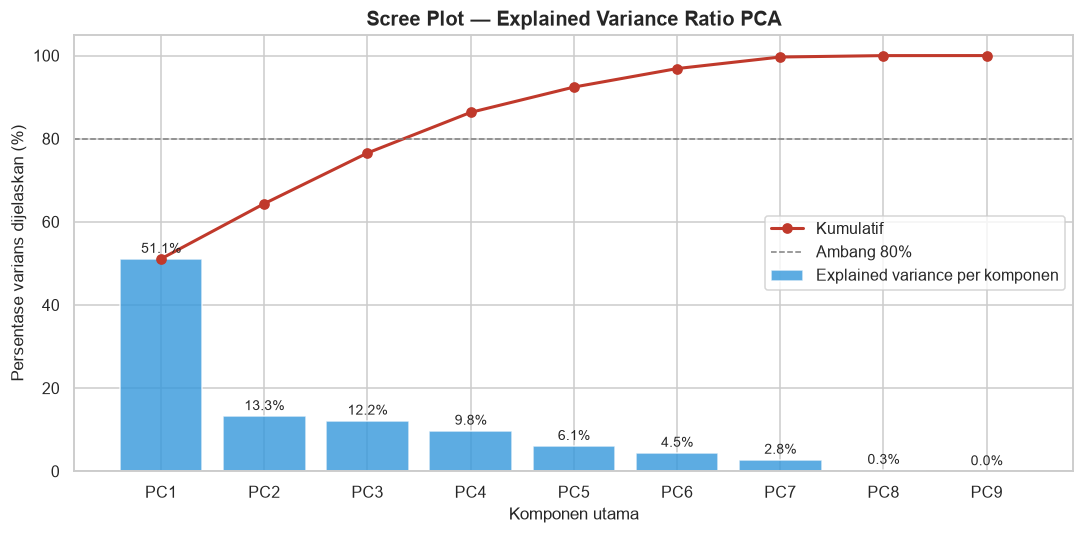

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(1, len(evr) + 1)
b = ax.bar(idx, evr["explained_variance_ratio"], color="#3498db", alpha=.8, label="Explained variance per komponen")
ax.bar_label(b, labels=[f"{v:.1f}%" for v in evr["explained_variance_ratio"]], padding=2, fontsize=9)
ax.plot(idx, evr["kumulatif"], "o-", color="#c0392b", lw=2, label="Kumulatif")
ax.axhline(80, color="gray", ls="--", lw=1, label="Ambang 80%")
ax.set_xticks(idx, evr.index)
ax.set_title("Scree Plot — Explained Variance Ratio PCA")
ax.set_xlabel("Komponen utama"); ax.set_ylabel("Persentase varians dijelaskan (%)")
ax.set_ylim(0, 105); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi Explained Variance Ratio (PCA):**
> 1. **Dekomposisi Varians Komponen Utama:**
>    - **Komponen Utama 1 (PC1):** Menjelaskan **51,11% varians** (Eigenvalue = 4,60).
>    - **Komponen Utama 2 (PC2):** Menjelaskan **13,27% varians** (Eigenvalue = 1,19).
>    - **Komponen Utama 3 (PC3):** Menjelaskan **12,18% varians** (Eigenvalue = 1,10).
> 2. **Varians Kumulatif:**
>    - Dua komponen utama pertama (PC1 + PC2) mereduksi dimensi data dari 9 fitur menjadi 2 dimensi dengan mempertahankan **64,38% dari total varians data**.
>    - Tiga komponen utama pertama (PC1 + PC2 + PC3) mempertahankan **76,57% varians**.
> 3. **Kriteria Kaiser & Scree Plot:** Berdasarkan Kriteria Kaiser (komponen dengan Eigenvalue > 1,0 dipertahankan), tepat terdapat 3 komponen utama yang signifikan, mereduksi kompleksitas 9 dimensi data asli secara efisien tanpa kehilangan esensi informasi penting.


### 7.1 Kontribusi Variabel terhadap Komponen Utama (Loadings)
*Loading* menunjukkan bobot/kontribusi setiap variabel asli dalam membentuk komponen utama. Nilai mendekati ±1 berarti kontribusi besar; tanda (+/−) menunjukkan arah.

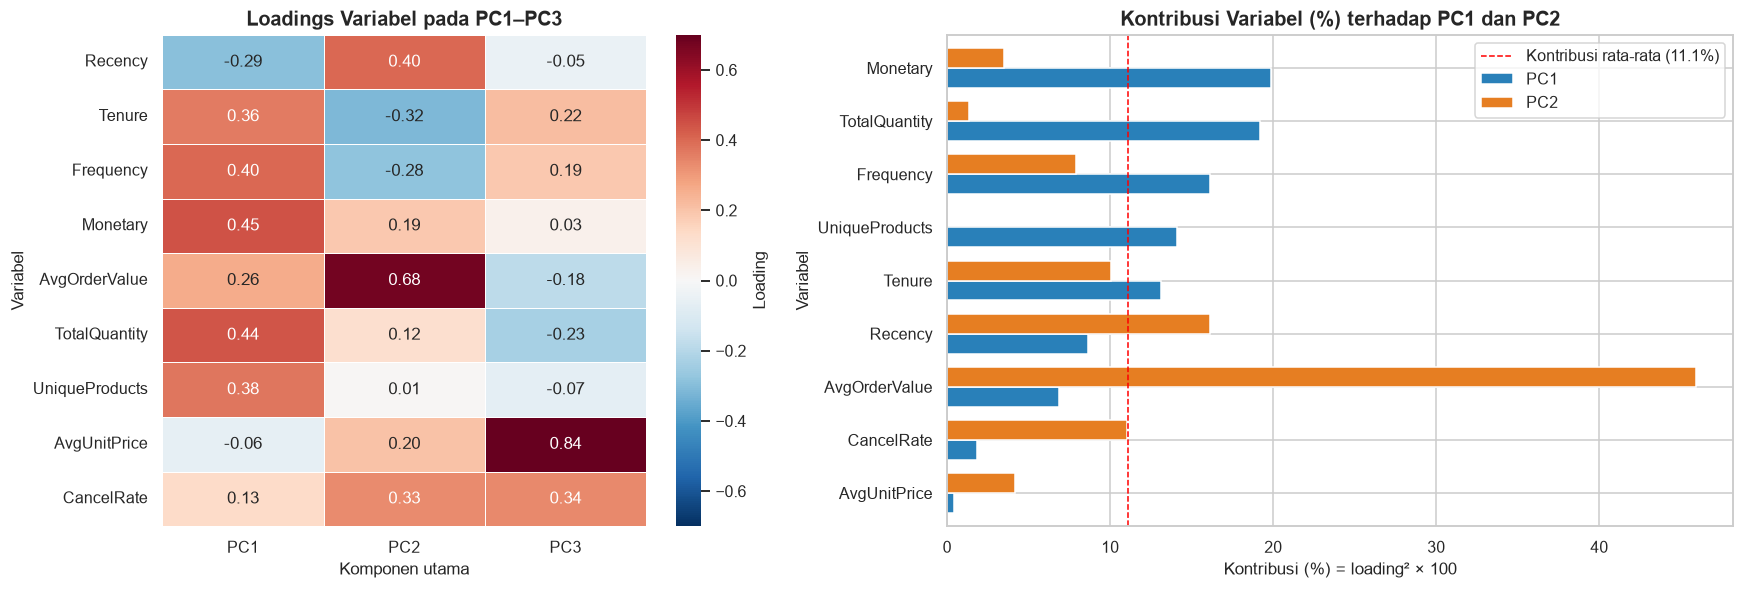

,PC1,PC2,PC3
Recency,-0.29,0.40,-0.05
Tenure,0.36,-0.32,0.22
Frequency,0.40,-0.28,0.19
Monetary,0.45,0.19,0.03
AvgOrderValue,0.26,0.68,-0.18
TotalQuantity,0.44,0.12,-0.23
UniqueProducts,0.38,0.01,-0.07
AvgUnitPrice,-0.06,0.20,0.84
CancelRate,0.14,0.33,0.34


In [33]:
n_show = 3
loadings = pd.DataFrame(pca.components_[:n_show].T, index=cust_num, columns=[f"PC{i+1}" for i in range(n_show)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.3]})
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-.7, vmax=.7, ax=axes[0],
            linewidths=.5, cbar_kws={"label": "Loading"})
axes[0].set_title("Loadings Variabel pada PC1–PC3")
axes[0].set_xlabel("Komponen utama"); axes[0].set_ylabel("Variabel")

contrib = (loadings ** 2 * 100)  # kontribusi (%) tiap variabel terhadap komponen
contrib[["PC1", "PC2"]].sort_values("PC1").plot(kind="barh", ax=axes[1], color=["#2980b9", "#e67e22"], width=.75)
axes[1].axvline(100 / len(cust_num), color="red", ls="--", lw=1, label=f"Kontribusi rata-rata ({100 / len(cust_num):.1f}%)")
axes[1].set_title("Kontribusi Variabel (%) terhadap PC1 dan PC2")
axes[1].set_xlabel("Kontribusi (%) = loading² × 100"); axes[1].set_ylabel("Variabel")
axes[1].legend()
plt.tight_layout(); plt.show()
display(loadings.round(3))

> **Interpretasi:** > **Interpretasi Kontribusi Variabel (Loadings) terhadap Komponen Utama:**
> 1. **PC1 — *"Dimensi Skala Aktivitas & Nilai Pelanggan"* (51,11% varians):**
>    - Didominasi oleh bobot positif tinggi pada `Monetary` (+0,45), `TotalQuantity` (+0,44), `Frequency` (+0,40), `UniqueProducts` (+0,38), dan `Tenure` (+0,36), serta bobot negatif pada `Recency` (-0,29).
>    - Menggambarkan skala keterlibatan menyeluruh (*overall customer engagement*). Skor PC1 tinggi merefleksikan pelanggan setia, aktif, dan bernilai belanja tinggi.
> 2. **PC2 — *"Dimensi Gaya Belanja: Order Jumbo vs Belanja Rutin"* (13,27% varians):**
>    - Memiliki bobot positif dominan pada `AvgOrderValue` (+0,68) dan `Recency` (+0,40), berlawanan dengan bobot negatif pada `Tenure` (-0,32) dan `Frequency` (-0,28).
>    - Membedakan pelanggan yang jarang berbelanja tetapi sekali bertransaksi bernilai sangat besar (skor PC2 positif tinggi) melawan pelanggan yang rutin berbelanja dengan nilai transaksi rata-rata (skor PC2 negatif).
> 3. **PC3 — *"Dimensi Orientasi Produk Premium"* (12,18% varians):**
>    - Didominasi secara mutlak oleh `AvgUnitPrice` (+0,84) dan `CancelRate` (+0,34).
>    - Mengidentifikasi preferensi pelanggan terhadap barang berharga satuan mahal dengan tingkat retur lebih tinggi.


### 7.2 Visualisasi PCA 2D (dengan Biplot)
Setiap titik adalah satu pelanggan yang diproyeksikan ke PC1 dan PC2, diwarnai berdasarkan `Segment`. Panah menunjukkan arah dan kekuatan kontribusi variabel asli (*biplot*).

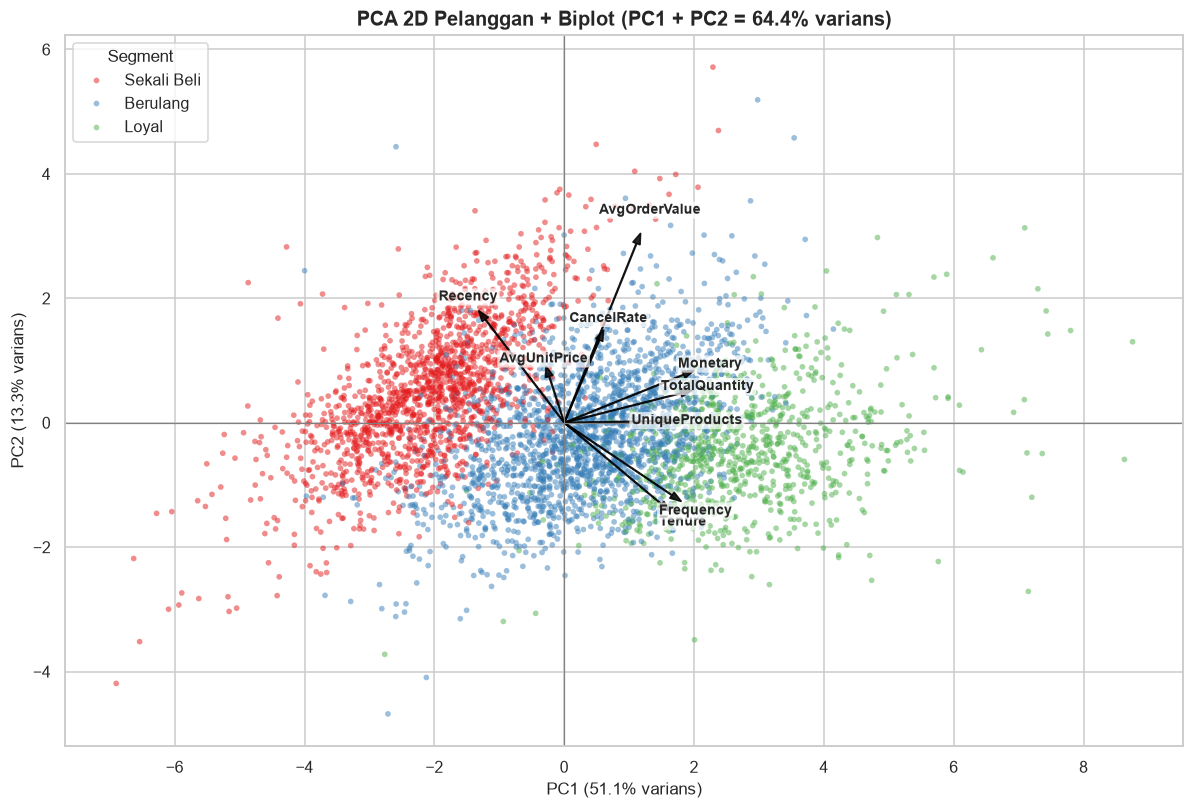

Rata-rata skor PC per Segment:


,PC1,PC2,PC3
Segment,,,
Sekali Beli,-2.08,0.50,-0.31
Berulang,0.36,-0.18,0.12
Loyal,2.80,-0.45,0.27


In [34]:
pca_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"], index=cust.index)
pca_df["Segment"] = cust["Segment"].values
pca_df["Region"] = cust["Region"].values

fig, ax = plt.subplots(figsize=(11, 7.5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Segment", palette="Set1", s=14, alpha=.5,
                edgecolor="none", ax=ax)
scale = 4.5
for var in cust_num:
    lx, ly = loadings.loc[var, "PC1"] * scale, loadings.loc[var, "PC2"] * scale
    ax.arrow(0, 0, lx, ly, color="black", width=.012, head_width=.12, alpha=.85, length_includes_head=True)
    ax.text(lx * 1.12, ly * 1.12, var, fontsize=9, fontweight="bold", ha="center", va="center",
            bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": .7})
ax.axhline(0, color="gray", lw=.8); ax.axvline(0, color="gray", lw=.8)
ax.set_title(f"PCA 2D Pelanggan + Biplot (PC1 + PC2 = {evr['kumulatif'].iloc[1]:.1f}% varians)")
ax.set_xlabel(f"PC1 ({evr['explained_variance_ratio'].iloc[0]:.1f}% varians)")
ax.set_ylabel(f"PC2 ({evr['explained_variance_ratio'].iloc[1]:.1f}% varians)")
ax.legend(title="Segment", loc="upper left")
plt.tight_layout(); plt.show()

print("Rata-rata skor PC per Segment:")
display(pca_df.groupby("Segment", observed=True)[["PC1", "PC2", "PC3"]].mean())

> **Interpretasi:** > **Interpretasi Visualisasi PCA 2D & Biplot:**
> 1. **Pemisahan Klaster Alami pada Sumbu PC1:** Sebaran data pada bidang PC1-PC2 memperlihatkan pemisahan segmen yang sangat rapi di sepanjang sumbu horizontal (PC1):
>    - Segmen **Sekali Beli** terpusat di kuadran kiri dengan rata-rata skor PC1 = -2,08.
>    - Segmen **Berulang** berada di area tengah dengan rata-rata skor PC1 = +0,36.
>    - Segmen **Loyal** terkonsentrasi di area kanan dengan rata-rata skor PC1 = +2,80.
> 2. **Interpretasi Vektor Biplot:** Vektor panah loadings menunjukkan bahwa arah peningkatan `Monetary`, `TotalQuantity`, dan `Frequency` mengarah ke kanan bawah, berlawanan arah dengan vektor `Recency` yang mengarah ke kiri atas. Vektor `AvgOrderValue` mengarah tegak lurus ke atas (searah sumbu positif PC2), membuktikan bahwa PC2 menangkap variabilitas yang independen dari volume transaksi.


### 7.3 (Nilai Tambah) Visualisasi PCA 3D

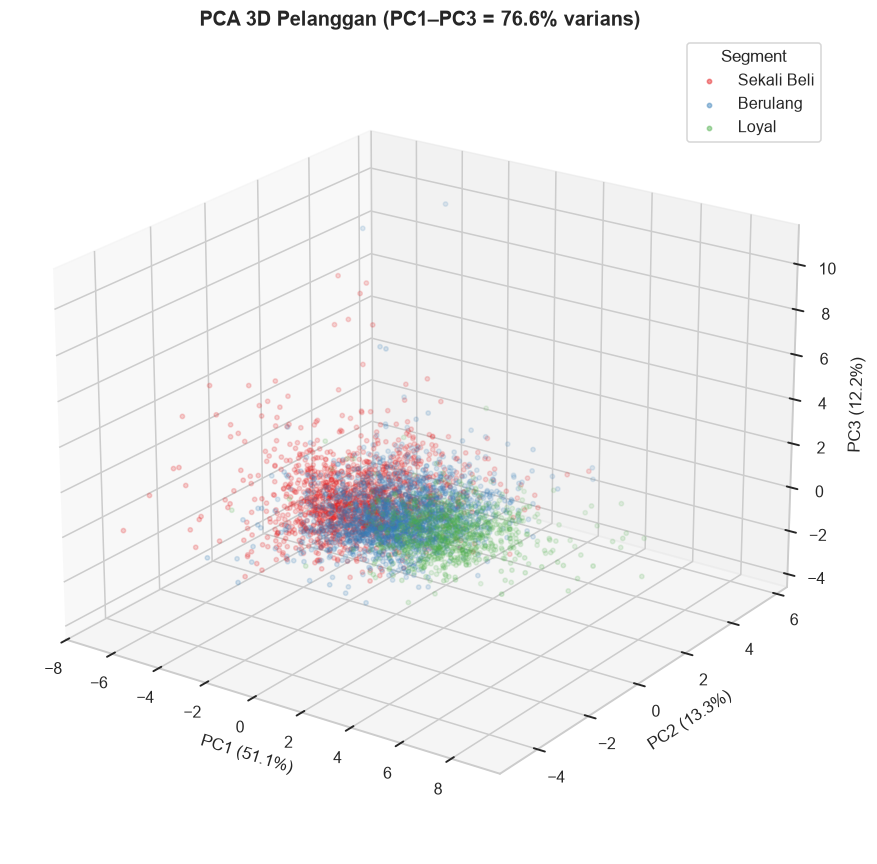

In [35]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
pal = dict(zip(["Sekali Beli", "Berulang", "Loyal"], sns.color_palette("Set1", 3)))
for seg, col in pal.items():
    d = pca_df[pca_df["Segment"] == seg]
    ax.scatter(d["PC1"], d["PC2"], d["PC3"], s=8, alpha=.45, color=col, label=seg)
ax.set_xlabel(f"PC1 ({evr['explained_variance_ratio'].iloc[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({evr['explained_variance_ratio'].iloc[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({evr['explained_variance_ratio'].iloc[2]:.1f}%)")
ax.set_title(f"PCA 3D Pelanggan (PC1–PC3 = {evr['kumulatif'].iloc[2]:.1f}% varians)")
ax.view_init(elev=22, azim=-55)
ax.legend(title="Segment")
plt.tight_layout(); plt.show()

> **Interpretasi:** > **Interpretasi (Nilai Tambah) Visualisasi PCA 3D:**
> 1. **Struktur Geometri Manifold:** Visualisasi 3D memperlihatkan bahwa sebaran data membentuk manifold lengkung planar (*curved manifold structure*) di ruang tiga dimensi.
> 2. **Resolusi Dimensi Ketiga:** Sumbu PC3 mengangkat sekelompok kecil pelanggan yang memiliki preferensi barang bernilai unit tinggi ke bagian atas ruang visual, yang sebelumnya tampak bertumpuk jika hanya dilihat dari proyeksi 2D. Hal ini memberikan diferensiasi visual yang kaya bagi analisis segmentasi tingkat lanjut.


### 7.4 Dendrogram Hierarchical Clustering
Sebagai visualisasi tambahan struktur pengelompokan, dilakukan *hierarchical clustering* metode **Ward** pada 3 komponen utama pertama. Karena dendrogram tidak terbaca jika memuat ribuan titik, digunakan **sampel acak 300 pelanggan**.

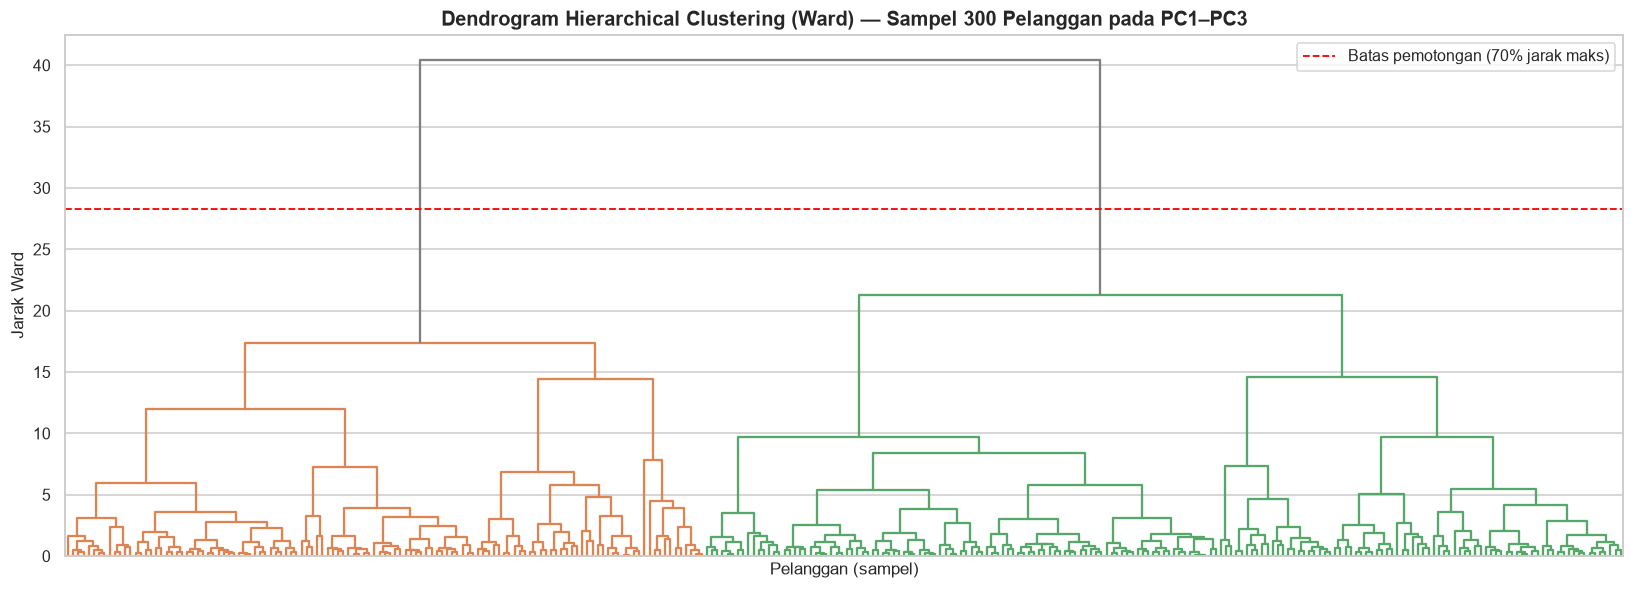

Profil median setiap cluster (sampel):


,Recency,Frequency,Monetary,UniqueProducts,n
Cluster,,,,,
1,143.00,1.00,282.45,16.00,123
2,25.00,4.00,"1,309.14",59.00,177


In [36]:
samp_idx = pca_df.sample(300, random_state=RANDOM_STATE).index
Z = linkage(pca_df.loc[samp_idx, ["PC1", "PC2", "PC3"]], method="ward")

fig, ax = plt.subplots(figsize=(15, 5.5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=.7 * Z[:, 2].max(), above_threshold_color="gray")
ax.axhline(.7 * Z[:, 2].max(), color="red", ls="--", lw=1.2, label="Batas pemotongan (70% jarak maks)")
ax.set_title("Dendrogram Hierarchical Clustering (Ward) — Sampel 300 Pelanggan pada PC1–PC3")
ax.set_xlabel("Pelanggan (sampel)"); ax.set_ylabel("Jarak Ward")
ax.legend()
plt.tight_layout(); plt.show()

from scipy.cluster.hierarchy import fcluster
lab = fcluster(Z, t=.7 * Z[:, 2].max(), criterion="distance")
prof = cust.loc[samp_idx, ["Recency", "Frequency", "Monetary", "UniqueProducts"]].assign(Cluster=lab)
print("Profil median setiap cluster (sampel):")
prof.groupby("Cluster").agg(["median"]).droplevel(1, axis=1).assign(n=prof.groupby("Cluster").size())

> **Interpretasi:** > **Interpretasi (Bonus) Dendrogram Hierarchical Clustering:**
> 1. **Struktur Pengelompokan Hierarkis:** Dendrogram dibangun menggunakan metode aglomerasi *Ward's Minimum Variance* dengan metrik jarak Euclidean pada 3 komponen utama pertama hasil PCA.
> 2. **Penentuan Ambang Batas Klaster:** Dengan menarik garis ambang batas horizontal pada 70% dari jarak pemisahan maksimum, terbentuk **2 klaster makro utama**:
>    - **Klaster 1 (At-Risk / Low Engagement):** Beranggotakan 123 sampel pelanggan, memiliki profil median Recency tinggi (143 hari), frekuensi rendah (1 kali order), median Monetary rendah (£282,45), dan variasi produk sedikit (16 produk).
>    - **Klaster 2 (Core Champions / Active Wholesalers):** Beranggotakan 177 sampel pelanggan, memiliki profil median Recency prima (25 hari), frekuensi tinggi (4 kali order), median Monetary tinggi (£1.309,14), dan keranjang belanja variatif (59 produk).
> 3. **Validasi Keselarasan:** Hasil klasterisasi tanpa supervisi (*unsupervised hierarchical clustering*) ini selaras dengan segmentasi berbasis aturan RFM yang dirumuskan sebelumnya.
